In [13]:
# Importações
import sys
import os
import pathlib
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
from datetime import timedelta
import matplotlib.pyplot as plt

# Detecção do root folder
notebook_path = pathlib.Path().absolute()
root_folder = notebook_path.parent

# Adicionar src ao path
SRC_DIR = root_folder
sys.path.append(str(SRC_DIR))

# Importar módulos do projeto
from src.utils.serialization import load_checkpoint
from src.utils.reprodutibility import set_seed

# Importar as funções
from src.result_analysis.plots import ( 
    plot_predictions_with_context,
    plot_metrics_by_horizon,
    plot_full_series_with_d1_forecast,
    plot_predictions_extremes
)

from src.result_analysis.metrics import (
    compute_flow_metrics,
    print_metrics_summary
)

from src import (
    ConfigLoader, load_feature_config, load_split_config, load_config,
    HydroDataset, create_dataset_for_inference, create_temporal_split_with_gap,
    Seq2SeqHydro, train_model, predict_autoregressive,
    custom_collate_fn, get_device,
    compute_flow_metrics,
    print_metrics_summary,
    plot_predictions_with_context,
    plot_metrics_by_horizon
)


# Configurações de caminhos
CONFIG_DIR = root_folder / "config"
DATA_DIR = root_folder / "data"
PROCESSED_DIR = DATA_DIR / "processed_inference"
MODELS_DIR = root_folder / "models"

print(f"📁 Root folder: {root_folder}")
print(f"📁 Config: {CONFIG_DIR}")
print(f"📁 Processed data: {PROCESSED_DIR}")

📁 Root folder: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo
📁 Config: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\config
📁 Processed data: c:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\data\processed_inference


In [14]:
# Carregar configurações
print("\n⚙️ Carregando configurações...")
data_config = load_config(CONFIG_DIR / "data_config.yaml")
model_config = load_config(CONFIG_DIR / "model_config.yaml")
train_config = load_config(CONFIG_DIR / "training_config.yaml")

# Extrair configurações
stations = data_config["stations"]
flow_window_config = data_config["flow_window_config"]
climate_window_config = data_config["climate_window_config"]
temporal_features = data_config["temporal_features"]
api_k_list = data_config["api_k_list"]
static_keys = data_config["static_keys"]
static_attributes_dict = data_config["static_attributes"]
window_stride = data_config['split_config']['window_stride']
horizon = data_config["horizon"]
reference_dates = data_config["reference_dates"]

print(f"✓ {len(stations)} estações carregadas")
print(f"✓ Configurações de modelo carregadas")
print(f"✓ Configurações de treino carregadas")
print(f"✓ Atributos estáticos de {len(static_attributes_dict)} estações carregados")


⚙️ Carregando configurações...
✓ 3 estações carregadas
✓ Configurações de modelo carregadas
✓ Configurações de treino carregadas
✓ Atributos estáticos de 3 estações carregados


In [15]:
# Célula 3: Carregar dados processados
print("\n📊 Carregando dados processados...")
features_file = PROCESSED_DIR / "features_combined_inference.csv"

if not features_file.exists():
    raise FileNotFoundError(f"Arquivo de features não encontrado: {features_file}")

combined_df = pd.read_csv(features_file)
combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df = combined_df.set_index('date')

print(f"✓ Dados carregados: {len(combined_df)} dias")
print(f"  Período: {combined_df.index.min().date()} a {combined_df.index.max().date()}")
print(f"  Colunas: {len(combined_df.columns)}")


📊 Carregando dados processados...
✓ Dados carregados: 46 dias
  Período: 2026-02-15 a 2026-04-01
  Colunas: 112


In [16]:
# ANTES de criar o dataset
reference_date = pd.Timestamp('2026-03-16')

for station in [10100000, 13150000, 14100000]:
    # Copiar dados observados para forecast no passado
    mask_past = combined_df.index <= reference_date
    
    # precipitation_forecast
    combined_df.loc[mask_past, f'precipitation_forecast_{station}'] = \
        combined_df.loc[mask_past, f'precipitation_obs_{station}']
    
    # Médias móveis
    for ma in [3, 7, 15]:
        combined_df.loc[mask_past, f'precipitation_forecast_ma{ma}_{station}'] = \
            combined_df.loc[mask_past, f'precipitation_obs_ma{ma}_{station}']
    
    # Cumulativos
    for cum in [3, 5, 7, 10]:
        combined_df.loc[mask_past, f'precipitation_forecast_cum{cum}_{station}'] = \
            combined_df.loc[mask_past, f'precipitation_obs_cum{cum}_{station}']
    
    # APIs
    for k in [70, 80, 85, 90, 92, 95]:
        combined_df.loc[mask_past, f'api_forecast_k{k}_{station}'] = \
            combined_df.loc[mask_past, f'api_obs_k{k}_{station}']
    
    # Derivada
    combined_df.loc[mask_past, f'dP_forecast_dt_{station}'] = \
        combined_df.loc[mask_past, f'dP_obs_dt_{station}']

print("✅ Colunas de forecast preenchidas no passado")


✅ Colunas de forecast preenchidas no passado


In [17]:
# Preencher primeiro valor de dP_forecast_dt (para todas as estações)
for station in [10100000, 13150000, 14100000]:
    col = f'dP_forecast_dt_{station}'
    
    # Pegar primeiro índice não-NaN
    first_valid_idx = combined_df[col].first_valid_index()
    first_valid_value = combined_df.loc[first_valid_idx, col]
    
    # Preencher APENAS o primeiro NaN
    if pd.isna(combined_df.loc[combined_df.index[0], col]):
        combined_df.loc[combined_df.index[0], col] = first_valid_value
        print(f"✅ {col}: preenchido primeiro NaN com {first_valid_value:.4f}")

print("\n📊 Verificando primeira linha após correção:")
print(combined_df[[
    'dP_forecast_dt_10100000',
    'dP_forecast_dt_13150000', 
    'dP_forecast_dt_14100000'
]].head(3))

✅ dP_forecast_dt_10100000: preenchido primeiro NaN com -4.9432
✅ dP_forecast_dt_13150000: preenchido primeiro NaN com -9.0908
✅ dP_forecast_dt_14100000: preenchido primeiro NaN com -9.7050

📊 Verificando primeira linha após correção:
            dP_forecast_dt_10100000  dP_forecast_dt_13150000  \
date                                                           
2026-02-15                -4.943241                -9.090829   
2026-02-16                -4.943241                -9.090829   
2026-02-17                 4.949970                 3.863907   

            dP_forecast_dt_14100000  
date                                 
2026-02-15                -9.704957  
2026-02-16                -9.704957  
2026-02-17                 2.064317  


In [18]:
import numpy as np

def calculate_temporal_features(dates):
    """Calcula features temporais para um conjunto de datas."""
    # Converter para numpy datetime
    dates_np = dates.to_numpy().astype('datetime64[D]')
    
    # Dia do ano (1-366)
    day_of_year = (dates_np - dates_np.astype('datetime64[Y]')).astype(int) + 1
    
    # Mês (1-12)
    month = dates.month.to_numpy()
    
    # Normalizar e calcular seno/cosseno
    day_angle = 2 * np.pi * day_of_year / 366
    month_angle = 2 * np.pi * (month - 1) / 12
    
    return {
        'day_sin': np.sin(day_angle),
        'day_cos': np.cos(day_angle),
        'month_sin': np.sin(month_angle),
        'month_cos': np.cos(month_angle)
    }

# Identificar linhas com NaN nas features temporais
temporal_cols = ['day_sin', 'day_cos', 'month_sin', 'month_cos']
mask_missing = combined_df[temporal_cols].isna().any(axis=1)

if mask_missing.any():
    print(f"⚠️ {mask_missing.sum()} linhas sem features temporais")
    
    # Calcular features temporais para essas linhas
    missing_dates = combined_df[mask_missing].index
    temporal_feats = calculate_temporal_features(missing_dates)
    
    # Preencher
    for col, values in temporal_feats.items():
        combined_df.loc[mask_missing, col] = values
    
    print("✅ Features temporais calculadas para datas futuras")
    
    # Verificar
    print("\nPrimeiras 5 linhas do período de forecast (após correção):")
    print(combined_df[temporal_cols].iloc[30:35])
else:
    print("✅ Todas as linhas têm features temporais")

⚠️ 16 linhas sem features temporais
✅ Features temporais calculadas para datas futuras

Primeiras 5 linhas do período de forecast (após correção):
             day_sin   day_cos  month_sin  month_cos
date                                                
2026-03-17  0.964806  0.262962   0.866025        0.5
2026-03-18  0.969178  0.246361   0.866025        0.5
2026-03-19  0.973264  0.229688   0.866025        0.5
2026-03-20  0.977064  0.212947   0.866025        0.5
2026-03-21  0.980575  0.196143   0.866025        0.5


In [19]:
# Preencher primeiro valor de dP_obs_dt E dP_forecast_dt
for station in [10100000, 13150000, 14100000]:
    # dP_obs_dt (usado no ENCODER)
    col_obs = f'dP_obs_dt_{station}'
    if pd.isna(combined_df.loc[combined_df.index[0], col_obs]):
        first_valid_idx = combined_df[col_obs].first_valid_index()
        first_valid_value = combined_df.loc[first_valid_idx, col_obs]
        combined_df.loc[combined_df.index[0], col_obs] = first_valid_value
        print(f"✅ {col_obs}: preenchido com {first_valid_value:.4f}")
    
    # dP_forecast_dt (usado no DECODER)
    col_fc = f'dP_forecast_dt_{station}'
    if pd.isna(combined_df.loc[combined_df.index[0], col_fc]):
        first_valid_idx = combined_df[col_fc].first_valid_index()
        first_valid_value = combined_df.loc[first_valid_idx, col_fc]
        combined_df.loc[combined_df.index[0], col_fc] = first_valid_value
        print(f"✅ {col_fc}: preenchido com {first_valid_value:.4f}")

print("\n✅ Todas as derivadas preenchidas!")

✅ dP_obs_dt_10100000: preenchido com -4.9432
✅ dP_obs_dt_13150000: preenchido com -9.0908
✅ dP_obs_dt_14100000: preenchido com -9.7050

✅ Todas as derivadas preenchidas!


In [20]:
MODELS_DIR = root_folder / "models/modelo_hidrologico_to_operational_version.pth"

# Configuração
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Carregar Modelo e Metadados
print("📂 Carregando checkpoint...")
model, meta = load_checkpoint(MODELS_DIR, device=DEVICE)

📂 Carregando checkpoint...
⚠️ Aviso: Carregamento seguro falhou (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check t

In [21]:
# Criar forecast columns (mesmos dados para início)
forecast_cols = {}
for station in stations:
    forecast_cols[station] = (
        f'precipitation_forecast_{station}',
        #f'potential_evapotransp_forecast_{station}'
    )

In [22]:
# Recriar dataset com dados corrigidos
ds_inference = create_dataset_for_inference(
    df=combined_df,
    stations=stations,
    static_attrs=static_attributes_dict,
    forecast_cols=forecast_cols,
    flow_window_config=flow_window_config,
    climate_window_config=climate_window_config,
    temporal_features=temporal_features,
    api_k_list=api_k_list,
    static_keys=static_keys,
    reference_dates=['2026-03-16'],
    forcings="P"
)

# Copiar scalers de dP_obs_dt para dP_forecast_dt
from src.data.data_structures import Scaler

for station in [10100000, 13150000, 14100000]:
    obs_key = f'dP_obs_dt_{station}'
    fc_key = f'dP_forecast_dt_{station}'
    
    if obs_key in meta['climate_scalers']:
        # Copiar scaler de obs para forecast
        ds_inference.climate_scalers[fc_key] = meta['climate_scalers'][obs_key]
        print(f"✅ {fc_key}: copiado de {obs_key}")
        print(f"   mean={meta['climate_scalers'][obs_key].mean:.4f}, std={meta['climate_scalers'][obs_key].std:.4f}")
    else:
        print(f"❌ {obs_key} não encontrado!")

print("\n✅ Scalers de dP_forecast_dt configurados!")

# Injetar scalers
ds_inference.flow_scalers = meta["flow_scalers"]
ds_inference.climate_scalers = meta["climate_scalers"]
ds_inference.static_scalers = meta["static_scalers"]

# Copiar scalers de dP_obs_dt para dP_forecast_dt
for station in [10100000, 13150000, 14100000]:
    obs_key = f'dP_obs_dt_{station}'
    fc_key = f'dP_forecast_dt_{station}'
    if obs_key in meta['climate_scalers']:
        ds_inference.climate_scalers[fc_key] = meta['climate_scalers'][obs_key]

# Testar sample
sample = ds_inference[0]

print("\n🔬 INSPEÇÃO FINAL:")
print(f"encoder_dyn: Tem NaN? {torch.isnan(sample.encoder_dyn).any().item()}")
print(f"decoder_dyn: Tem NaN? {torch.isnan(sample.decoder_dyn).any().item()}")

if not torch.isnan(sample.encoder_dyn).any():
    print("\n🎯 SEM NaN! Executando previsão...")
    
    dl_inference = DataLoader(
        ds_inference,
        batch_size=1,
        shuffle=False,
        collate_fn=custom_collate_fn
    )
    
    preds, obs, baseline, g_seq, dates, _ = predict_autoregressive(
        model=model,
        loader=dl_inference,
        decoder_history=meta["decoder_history"],
        decoder_horizon=meta["decoder_horizon"],
        scalers=meta["flow_scalers"],
        stations=stations,
        clamp_non_negative=True,
        device=DEVICE
    )
    
    print(f"\n🎉 SUCESSO!")
    print(f"Shape: {preds.shape}")
    print(f"Tem NaN? {np.isnan(preds).any()}")
    
    print(f"\n📊 Previsões para estação 10100000:")
    print(preds[0, :, 0])
else:
    print("\n❌ Ainda há NaN no encoder!")
    
    # Debug: encontrar onde estão os NaN
    nan_mask = torch.isnan(sample.encoder_dyn)
    nan_positions = torch.where(nan_mask)
    print(f"\nPosições com NaN no encoder:")
    print(f"  Timesteps: {nan_positions[0][:10].tolist()}")
    print(f"  Features: {nan_positions[1][:10].tolist()}")

⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso: Desvio padrão muito baixo (0.0), ajustando para 1.0
⚠️ Aviso

In [24]:
preds

array([[[ 55139.906,  98579.875, 103764.81 ],
        [ 54733.934,  98446.3  , 103669.1  ],
        [ 54232.4  ,  98291.9  , 103551.664],
        [ 53547.47 ,  98114.26 , 103411.71 ],
        [ 52625.84 ,  97923.164, 103250.21 ],
        [ 51494.777,  97735.11 , 103070.555],
        [ 50225.97 ,  97562.58 , 102880.38 ],
        [ 48841.492,  97404.83 , 102680.95 ],
        [ 47403.504,  97260.51 , 102478.516],
        [ 45965.246,  97123.516, 102277.46 ],
        [ 44568.223,  96983.54 , 102078.97 ],
        [ 43204.35 ,  96827.71 , 101878.81 ],
        [ 41905.816,  96647.66 , 101678.37 ],
        [ 40647.38 ,  96428.13 , 101472.77 ],
        [ 39472.645,  96166.375, 101267.17 ]]], dtype=float32)

📈 Gerando gráficos de previsão...


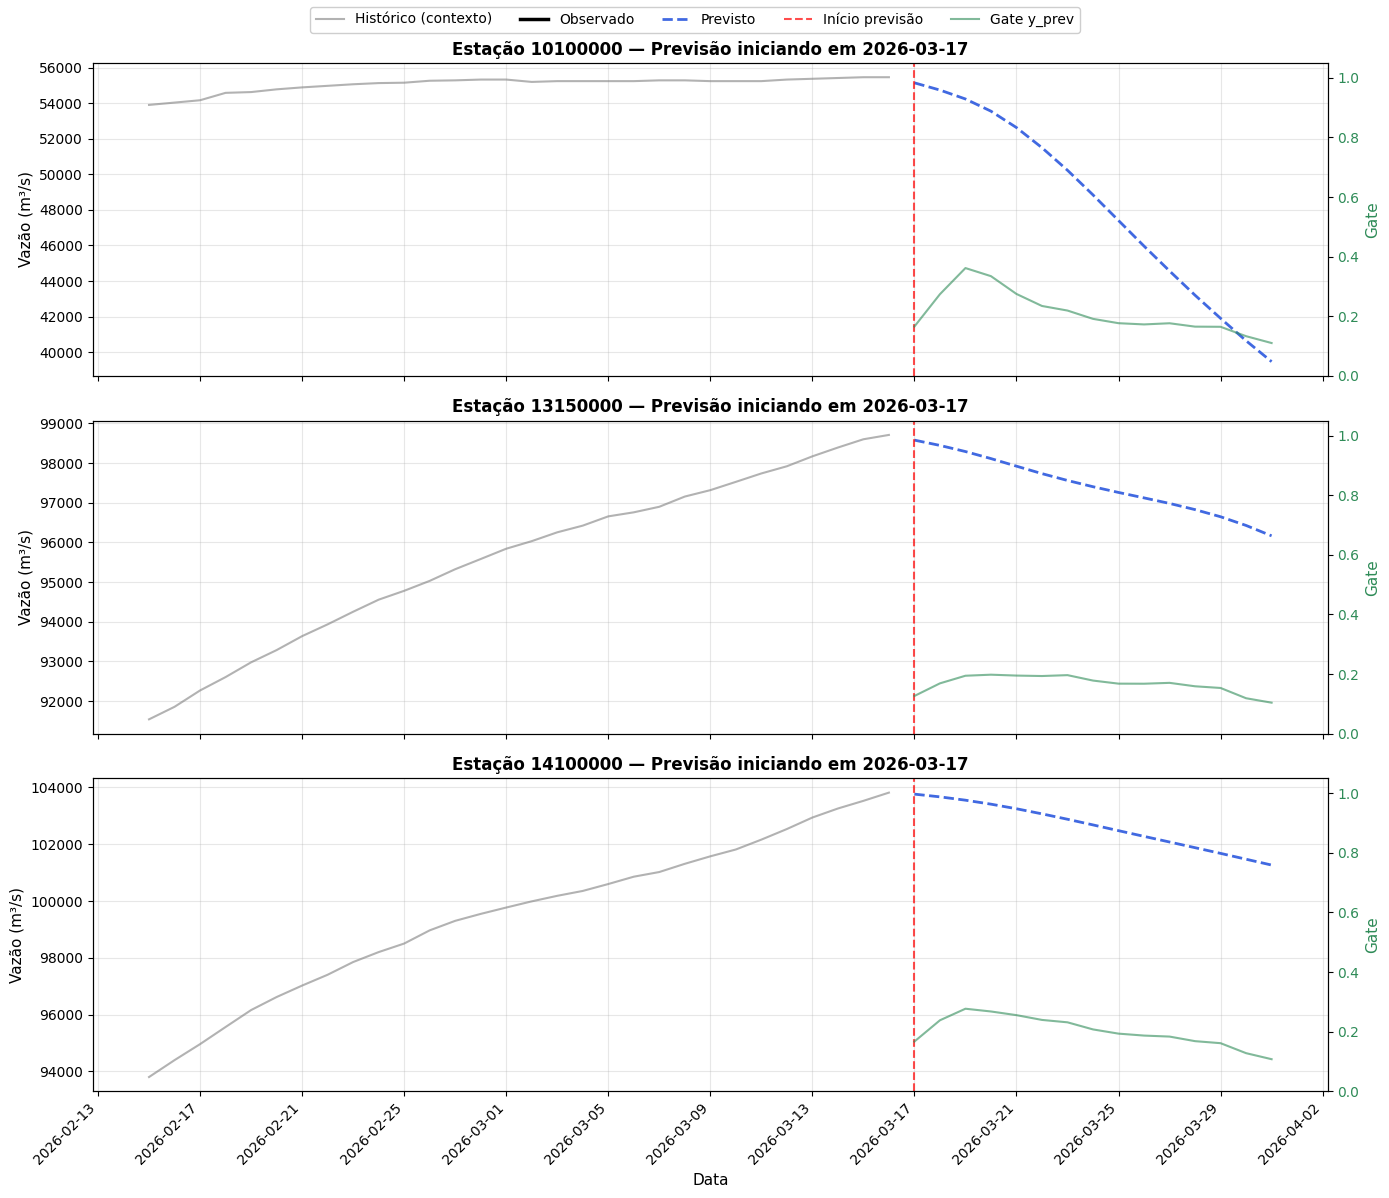

In [25]:
# 4. Plotar Previsões com Contexto
print("📈 Gerando gráficos de previsão...")
plot_predictions_with_context(
    preds=preds,
    obs=obs,
    stations=meta["stations"],
    df=combined_df,      # O dataframe original carregado anteriormente
    forecast_dates=dates,
    n_samples=1,         # Quantas amostras aleatórias plotar
    context_days=30,     # Dias de histórico para mostrar
    baseline_last=None,
    g_seq=g_seq
)

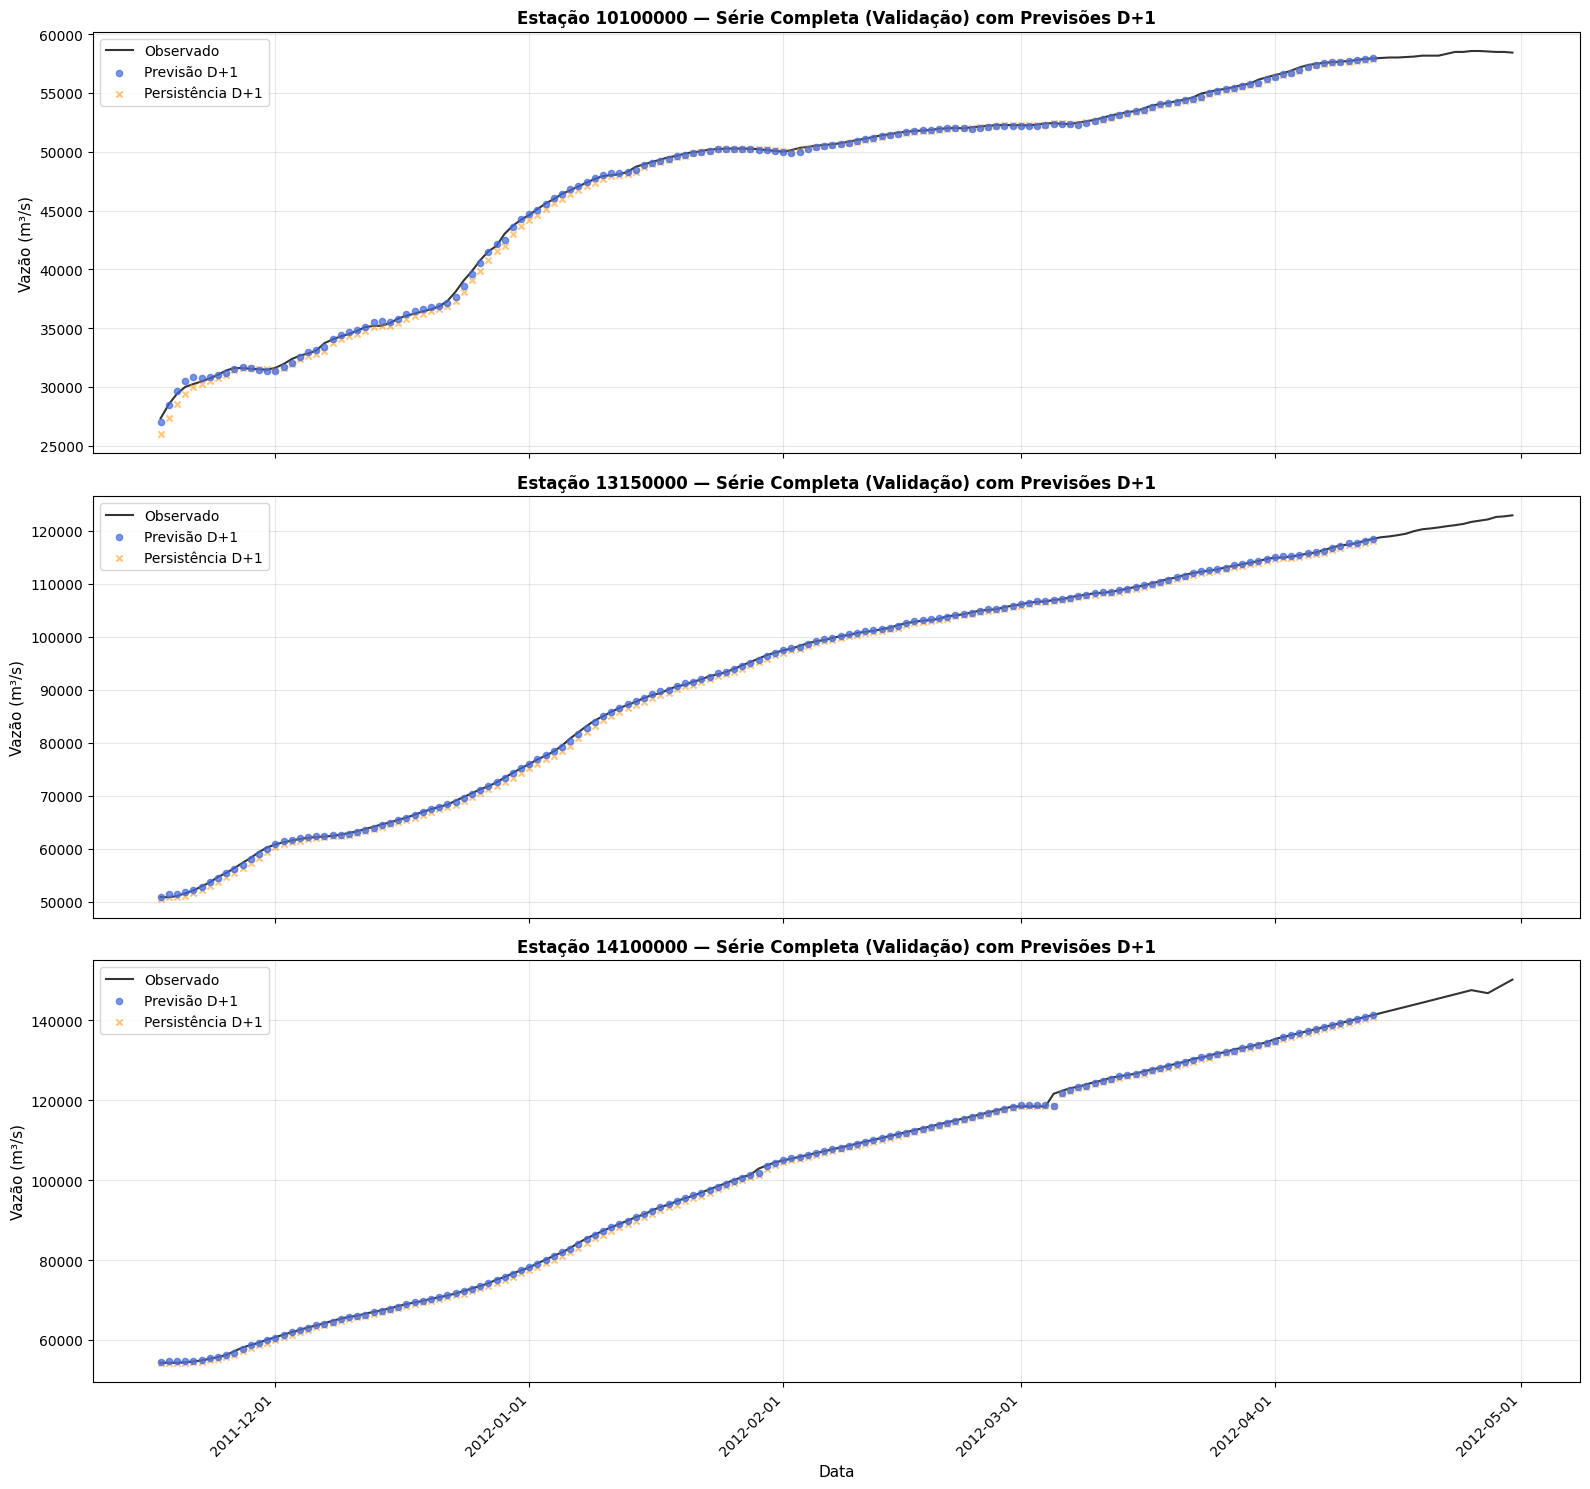

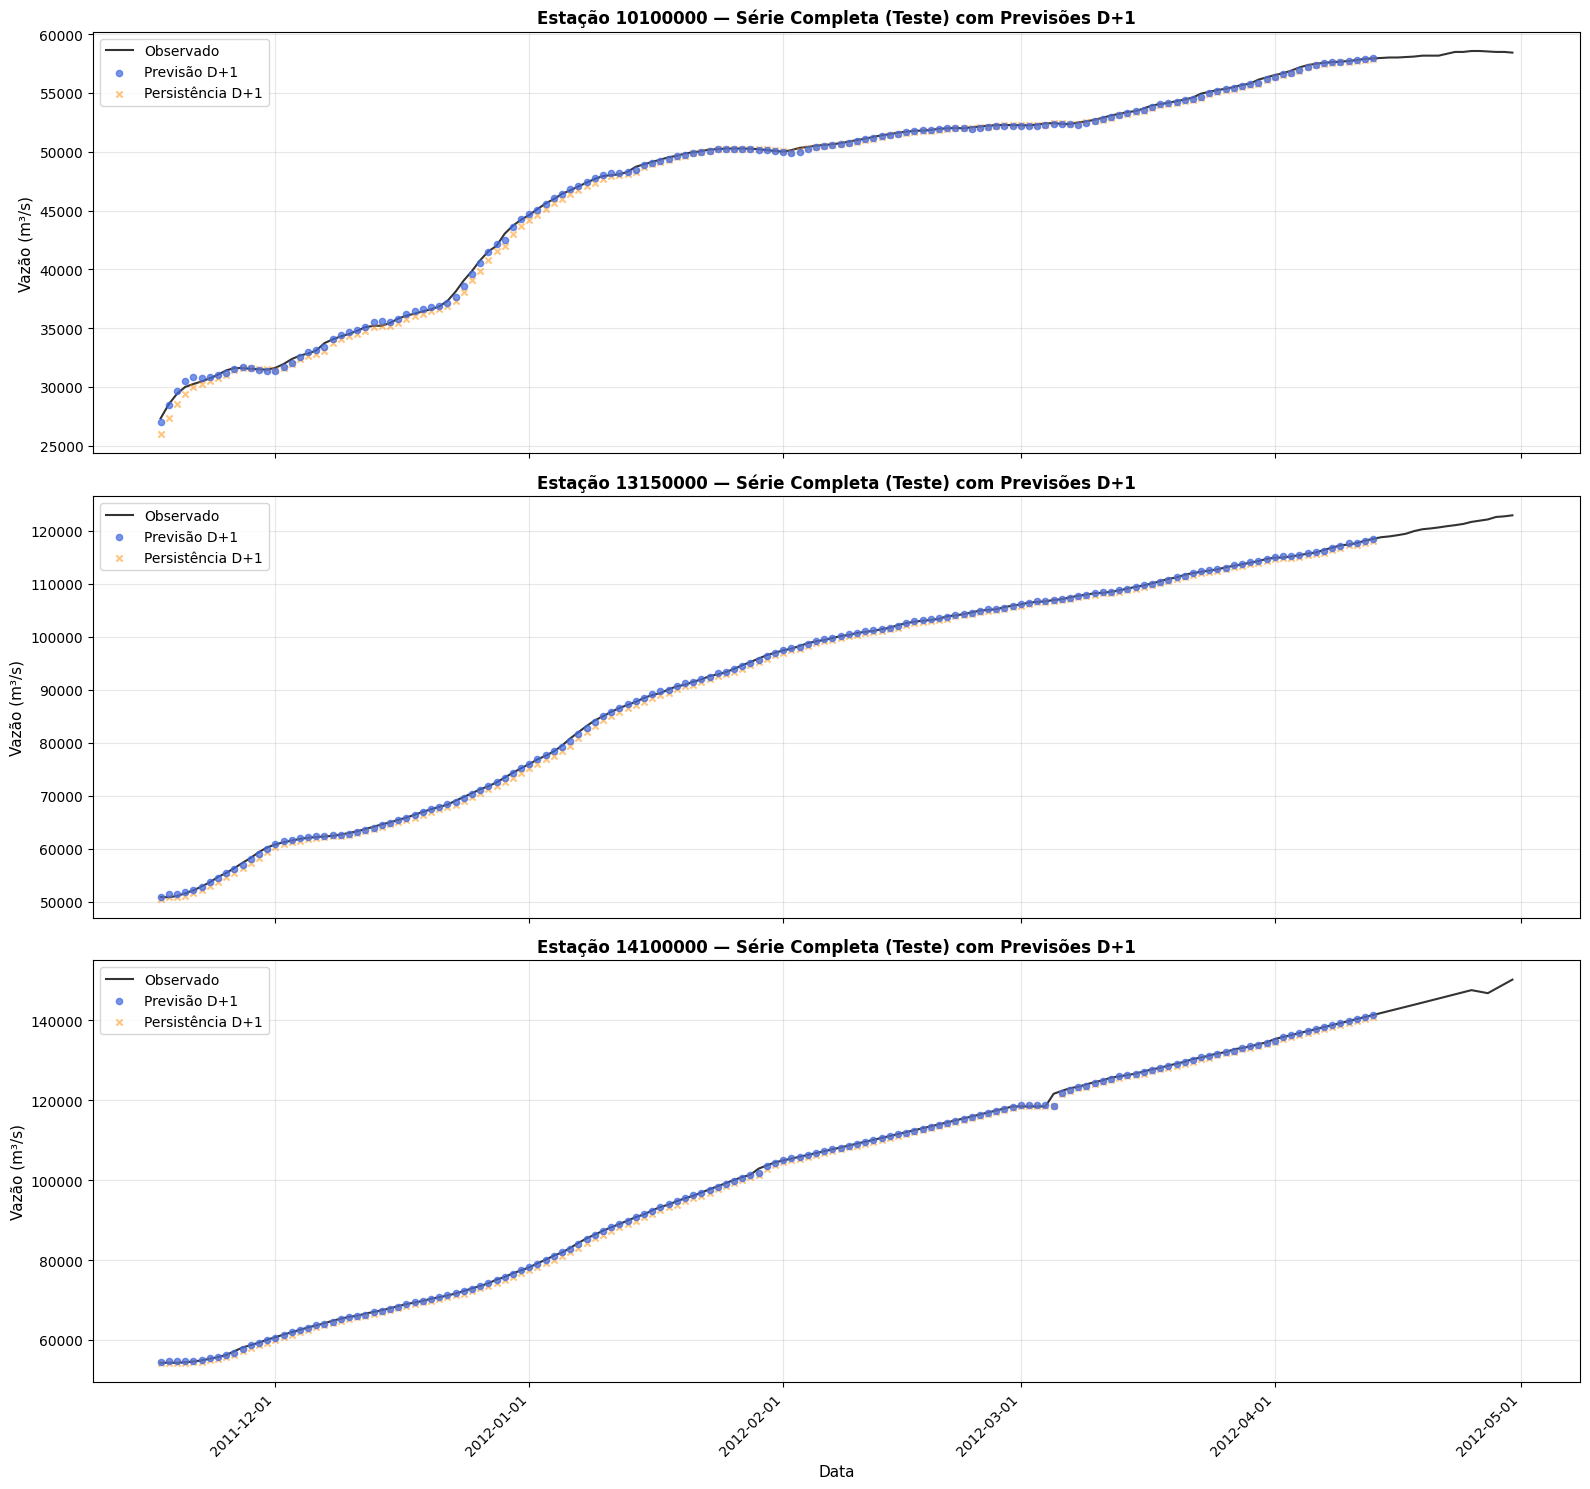


SELECIONANDO 3 EVENTOS MÁXIMOS

📊 Estação 10100000:
  Selecionados 3 eventos de MÁXIMA vazão
    1º: 2012-04-13 — Vazão média: 58268.96 m³/s
    2º: 2012-04-12 — Vazão média: 58239.39 m³/s
    3º: 2012-04-11 — Vazão média: 58201.07 m³/s



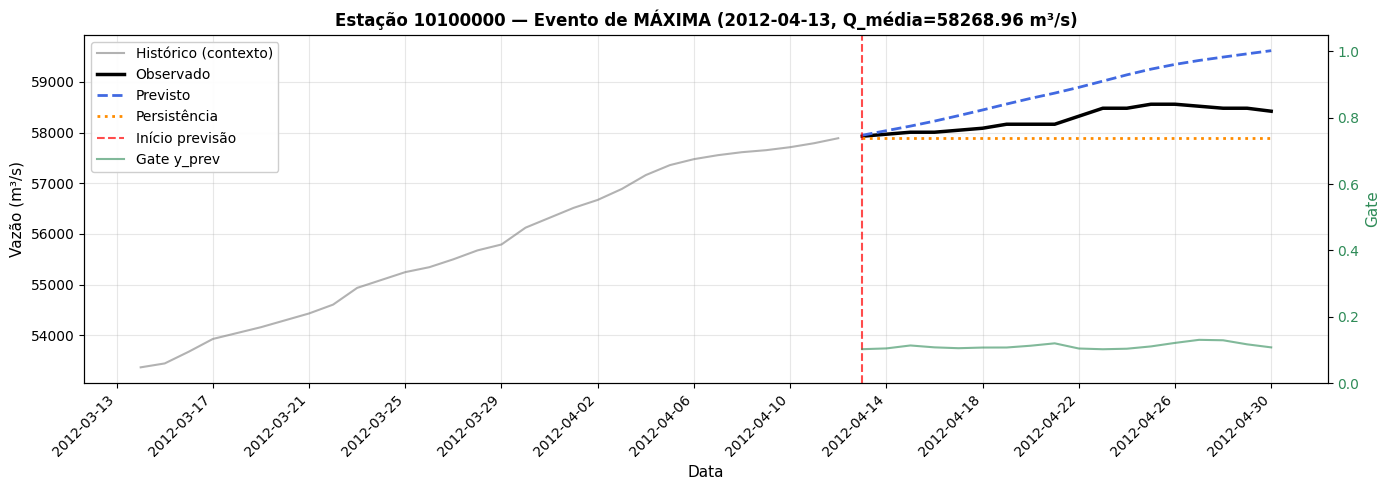

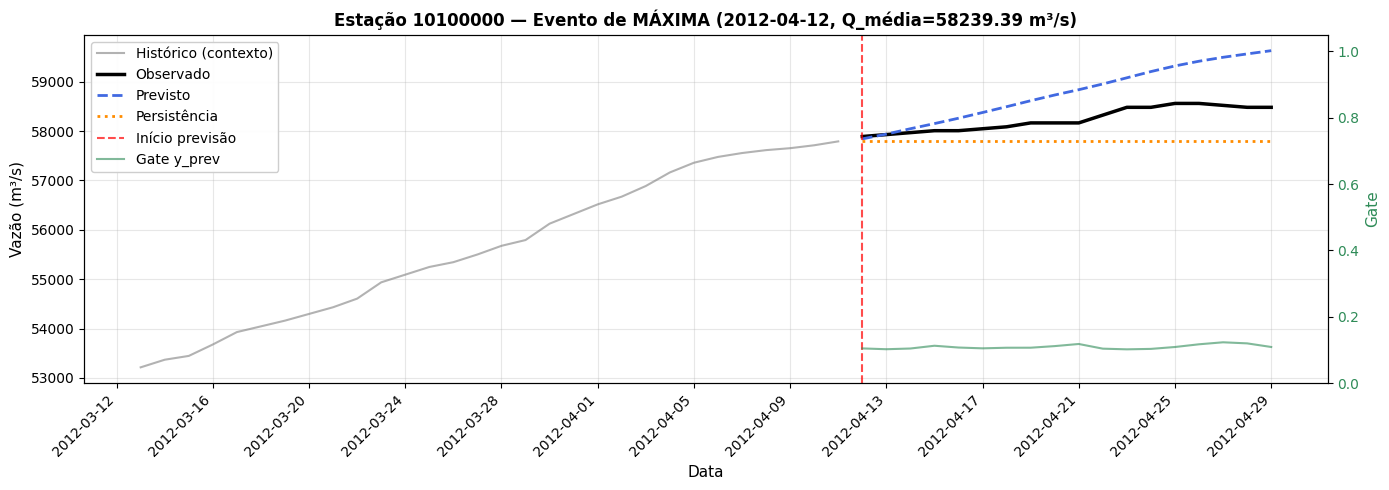

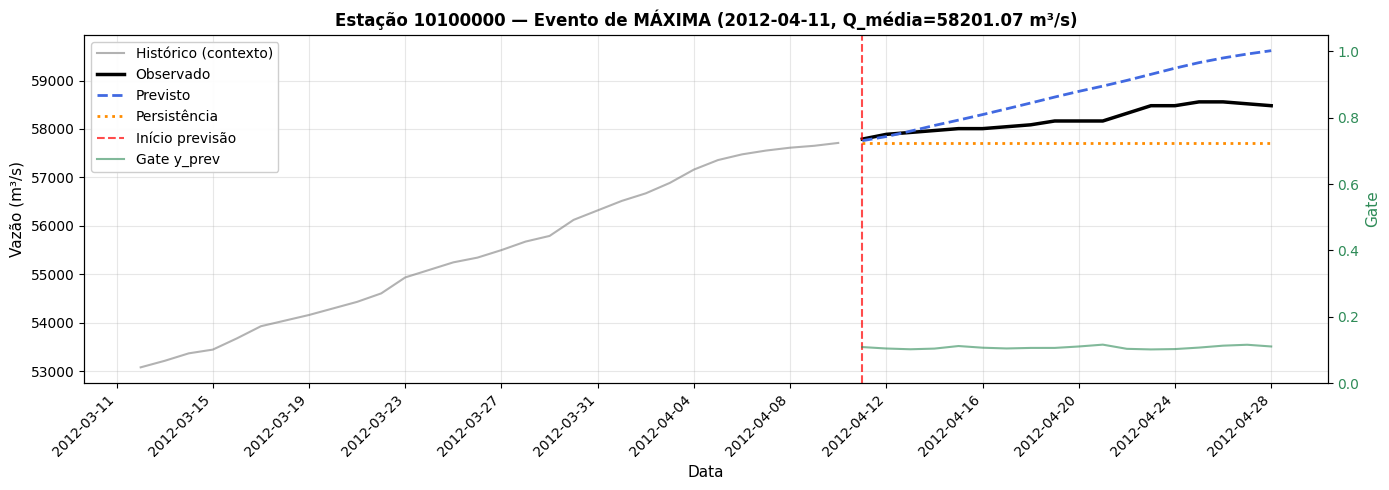

📊 Estação 13150000:
  Selecionados 3 eventos de MÁXIMA vazão
    1º: 2012-04-13 — Vazão média: 120717.18 m³/s
    2º: 2012-04-12 — Vazão média: 120451.72 m³/s
    3º: 2012-04-11 — Vazão média: 120171.68 m³/s



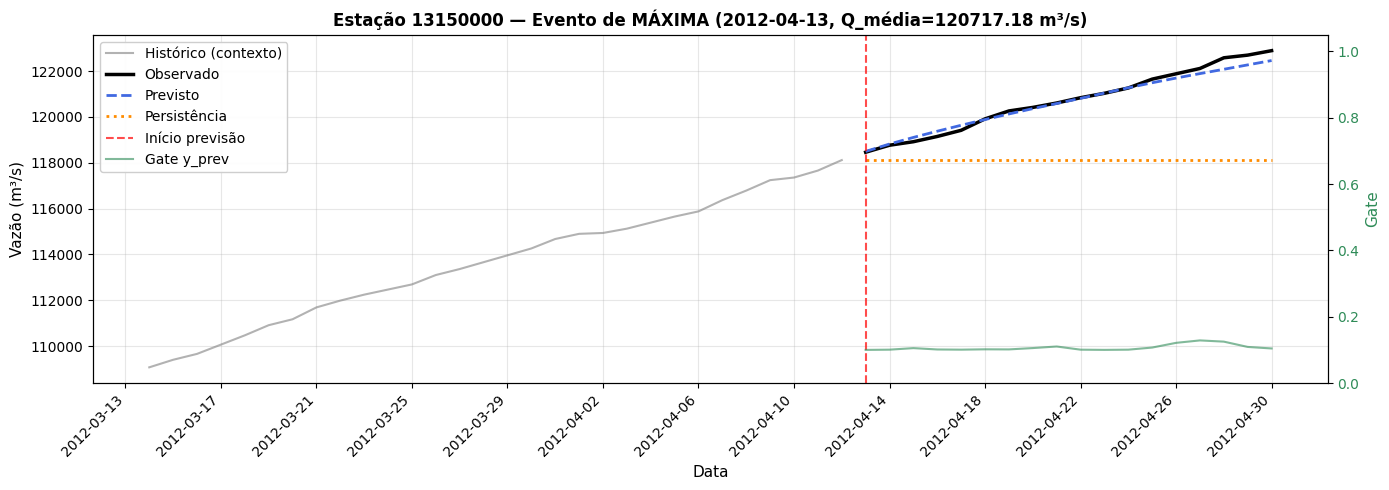

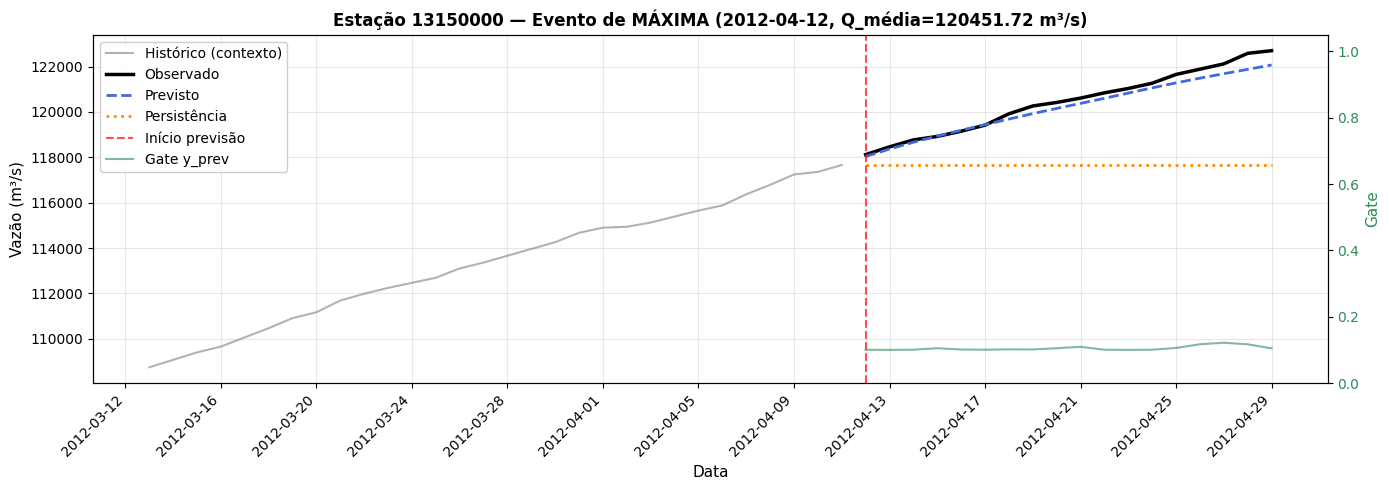

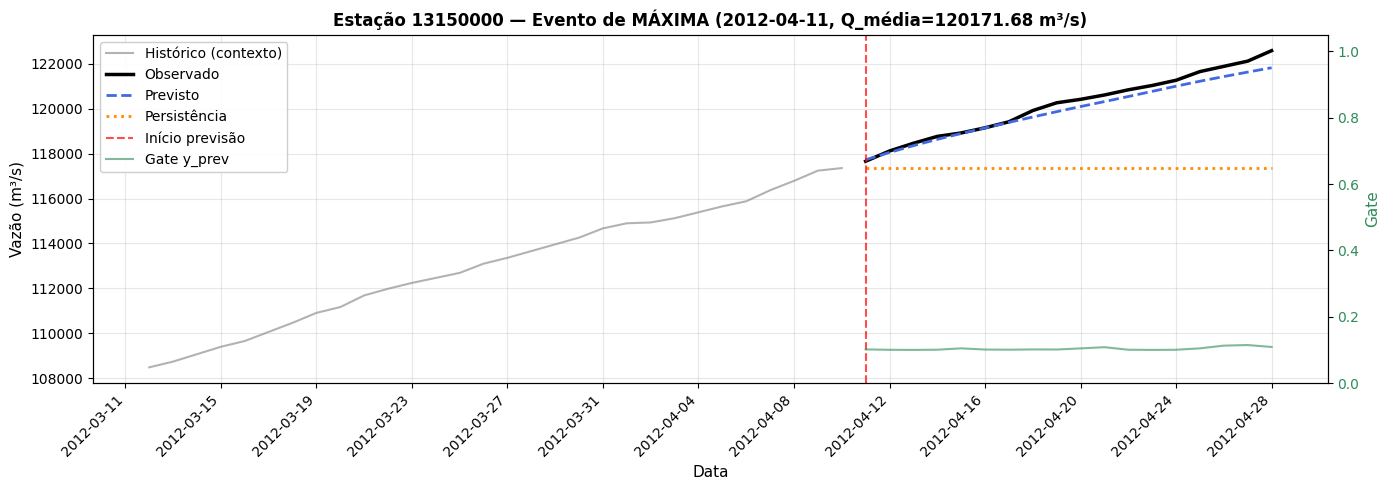

📊 Estação 14100000:
  Selecionados 3 eventos de MÁXIMA vazão
    1º: 2012-04-13 — Vazão média: 145494.80 m³/s
    2º: 2012-04-12 — Vazão média: 144974.64 m³/s
    3º: 2012-04-11 — Vazão média: 144489.47 m³/s



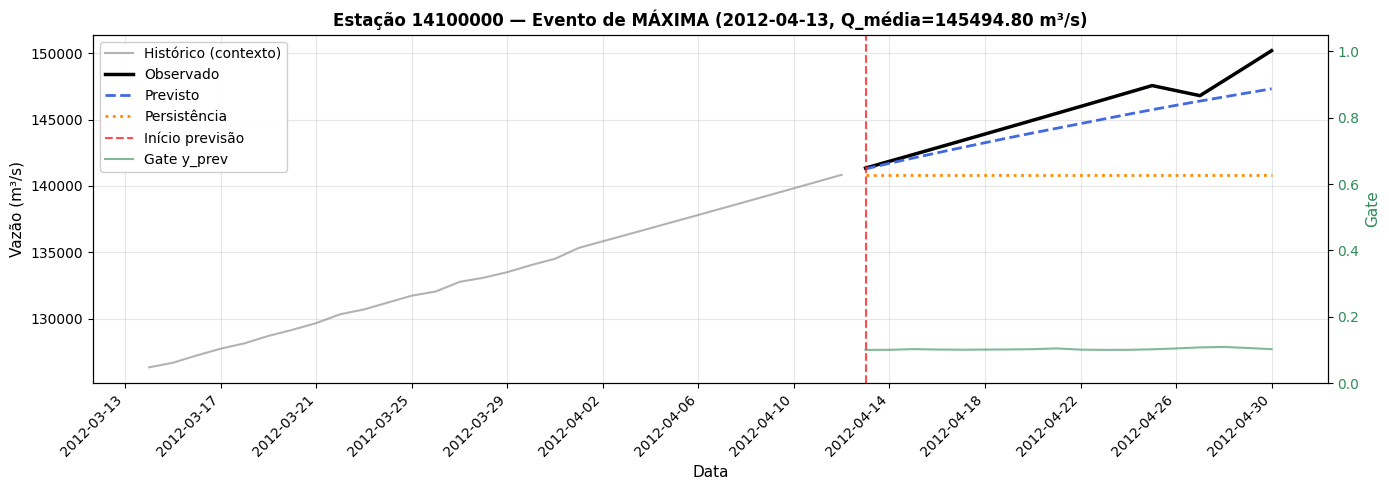

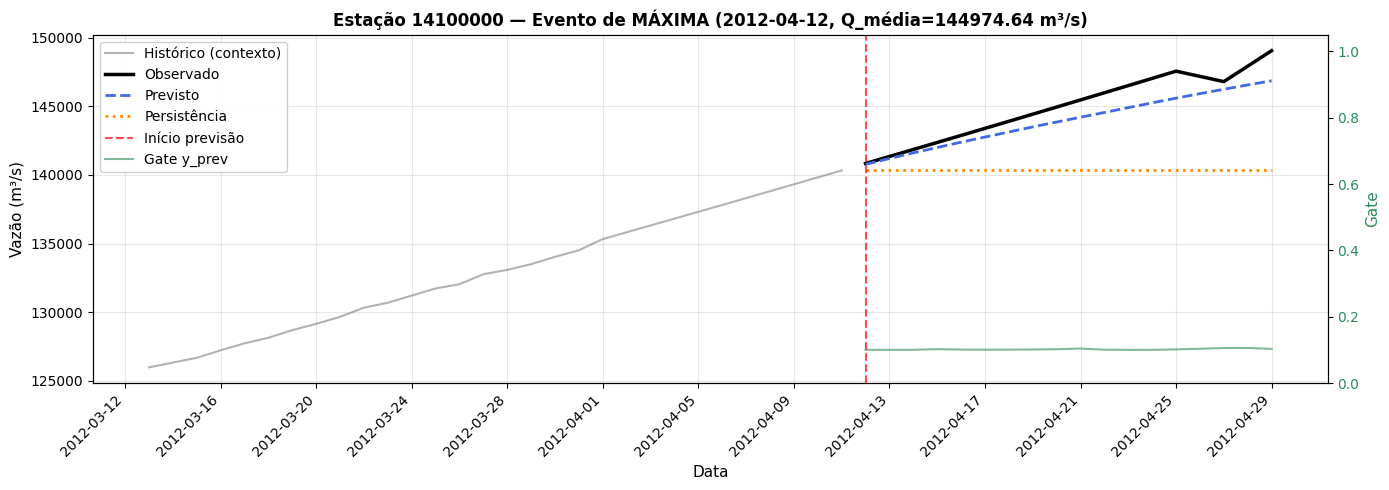

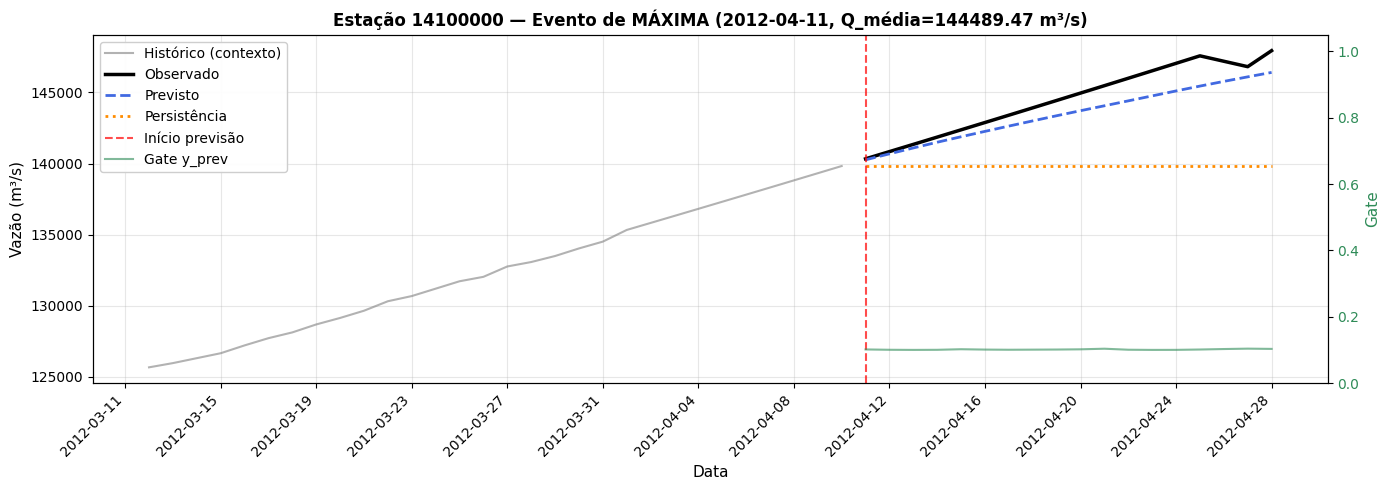

✅ VISUALIZAÇÃO DE EXTREMOS CONCLUÍDA


SELECIONANDO 5 EVENTOS MÍNIMOS

📊 Estação 10100000:
  Selecionados 5 eventos de MÍNIMA vazão
    1º: 2011-11-17 — Vazão média: 30863.87 m³/s
    2º: 2011-11-18 — Vazão média: 31170.11 m³/s
    3º: 2011-11-19 — Vazão média: 31423.54 m³/s
    4º: 2011-11-20 — Vazão média: 31662.71 m³/s
    5º: 2011-11-21 — Vazão média: 31886.82 m³/s



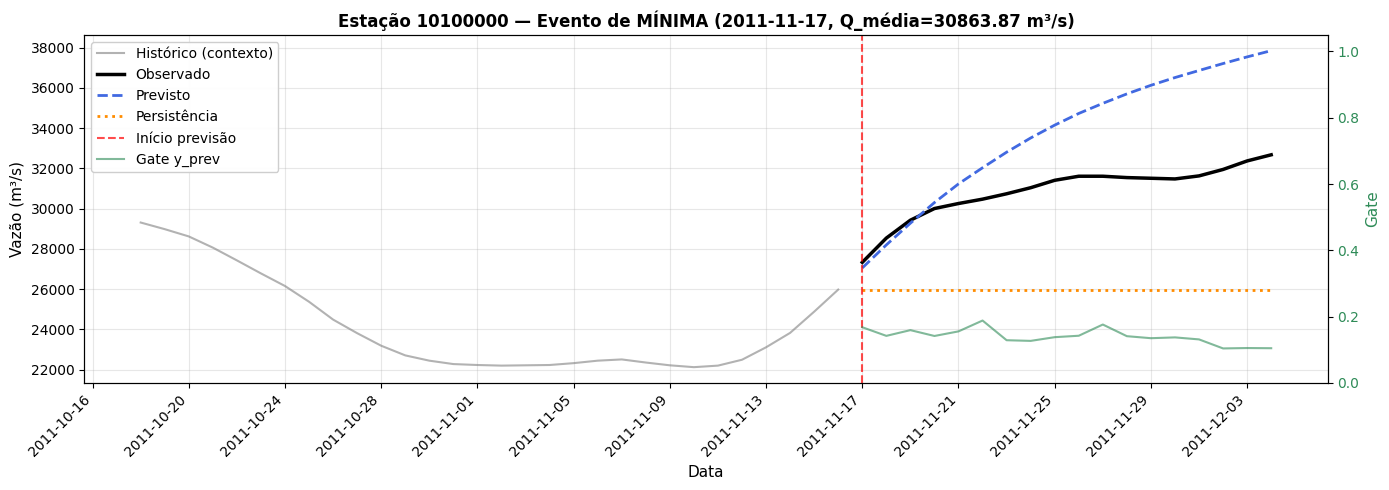

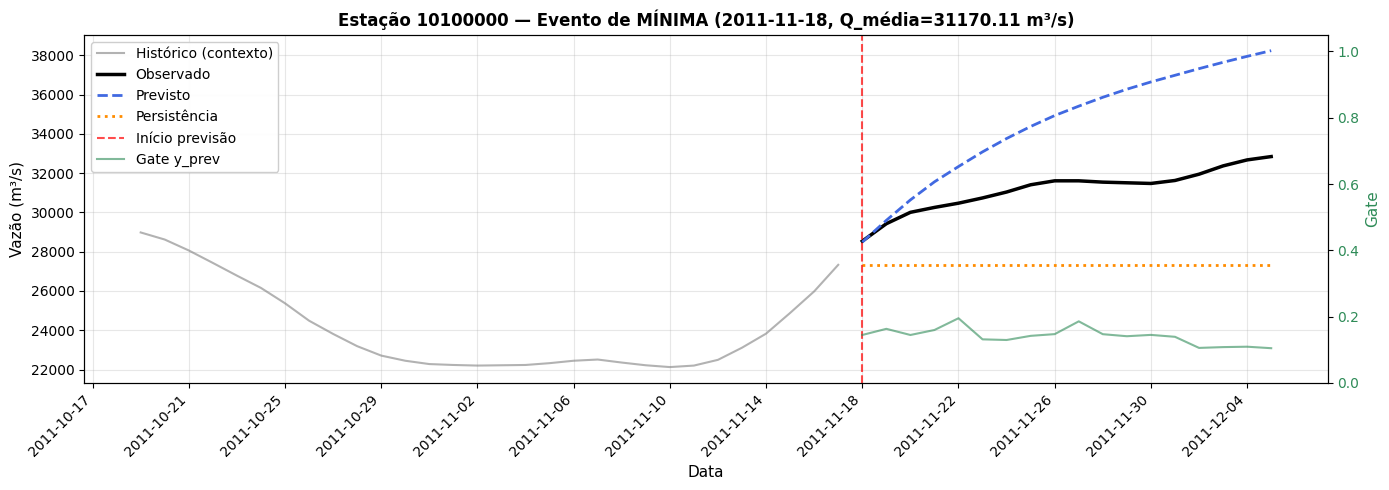

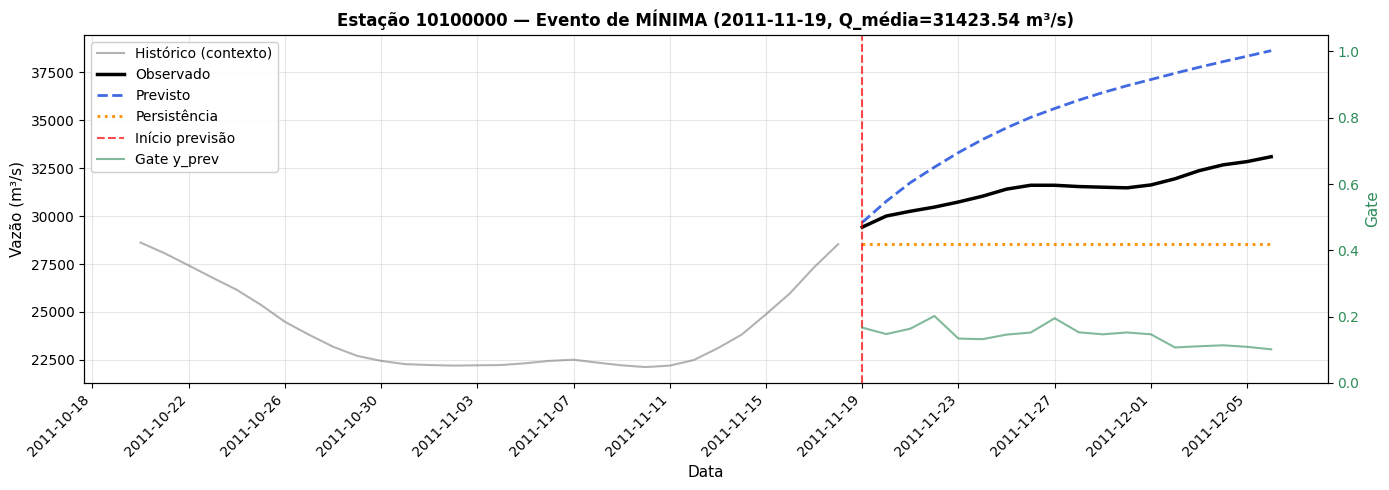

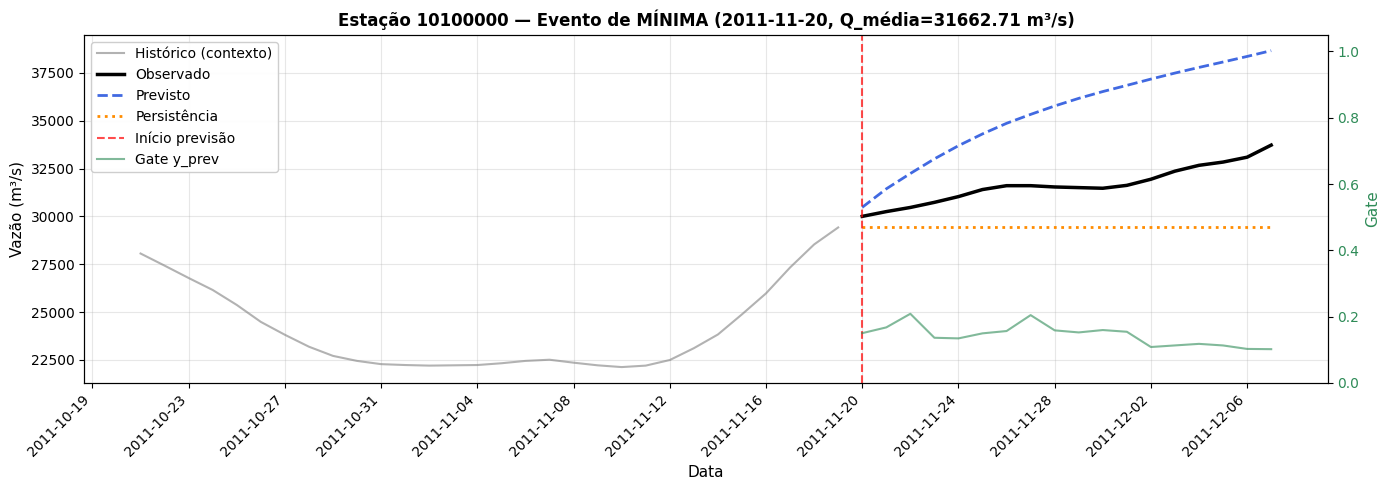

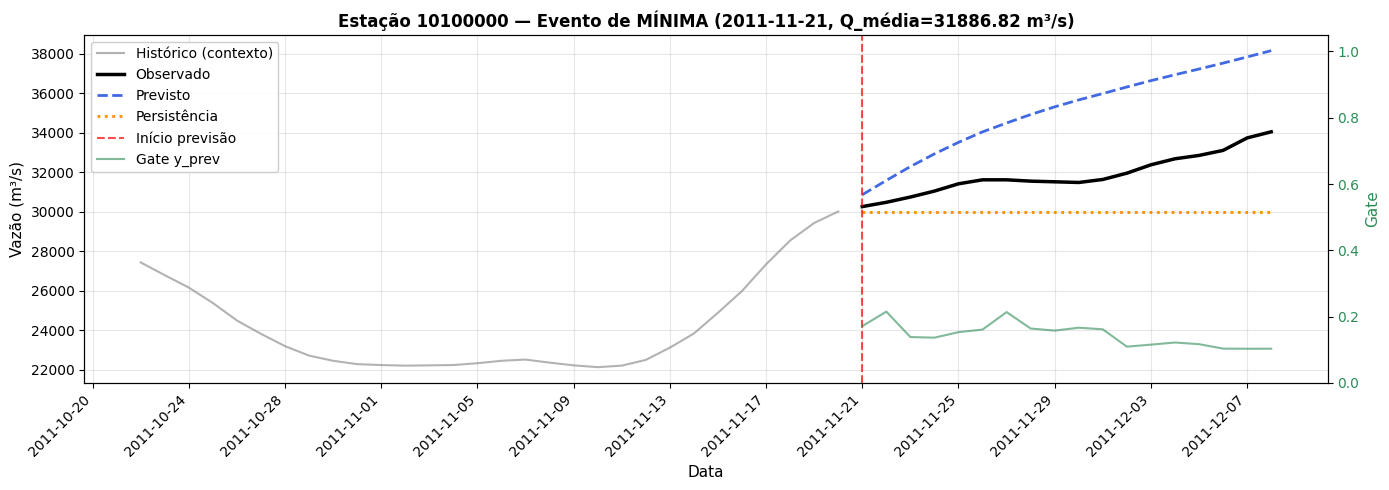

📊 Estação 13150000:
  Selecionados 5 eventos de MÍNIMA vazão
    1º: 2011-11-17 — Vazão média: 56107.64 m³/s
    2º: 2011-11-18 — Vazão média: 56728.56 m³/s
    3º: 2011-11-19 — Vazão média: 57359.92 m³/s
    4º: 2011-11-20 — Vazão média: 57983.55 m³/s
    5º: 2011-11-21 — Vazão média: 58585.50 m³/s



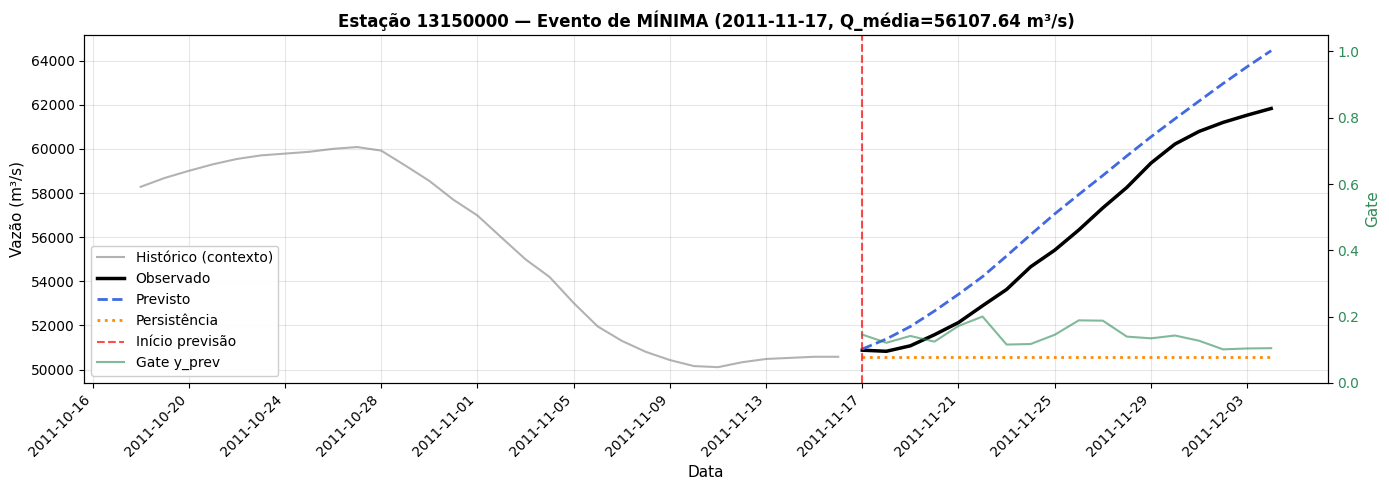

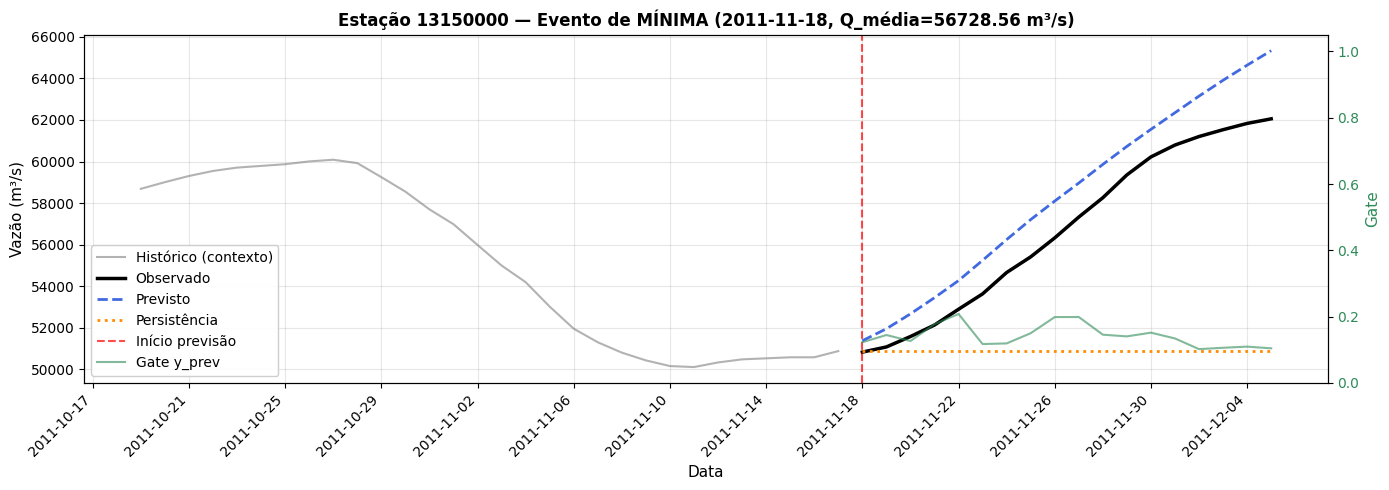

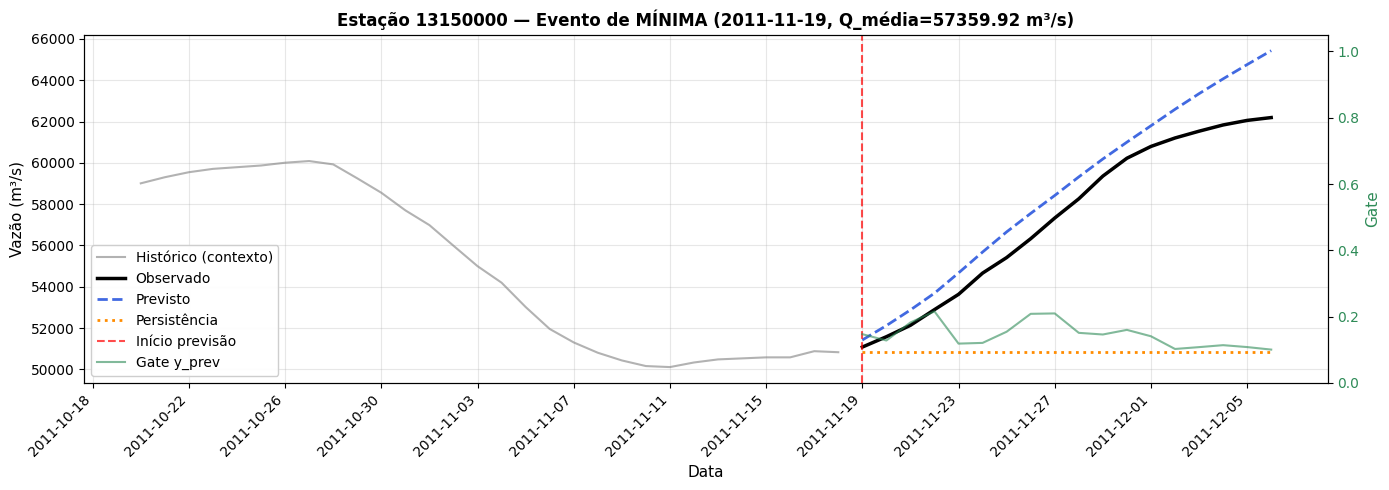

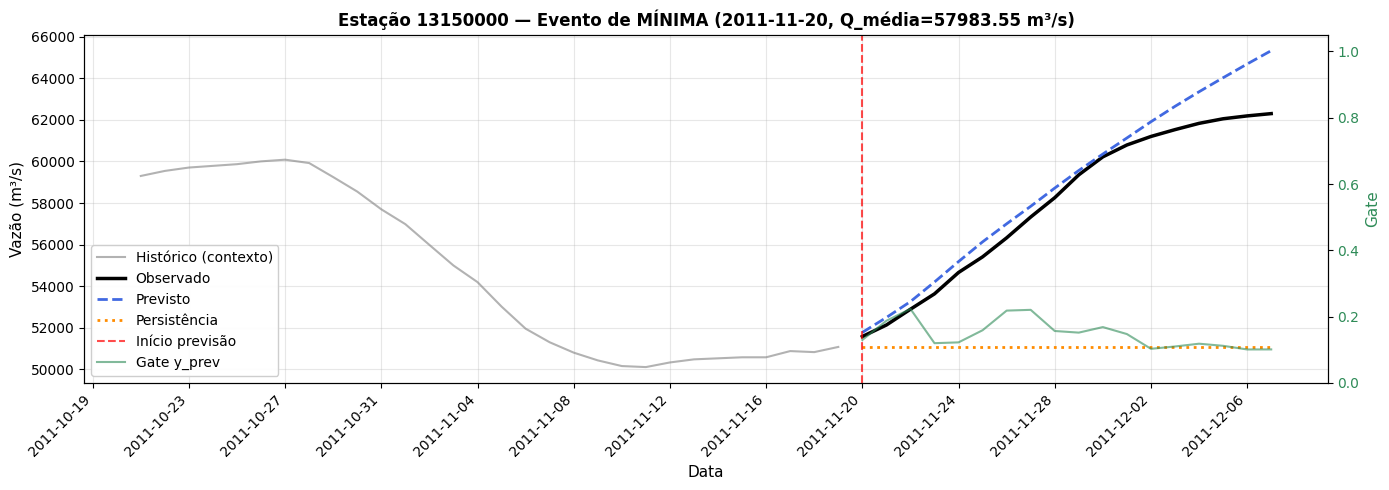

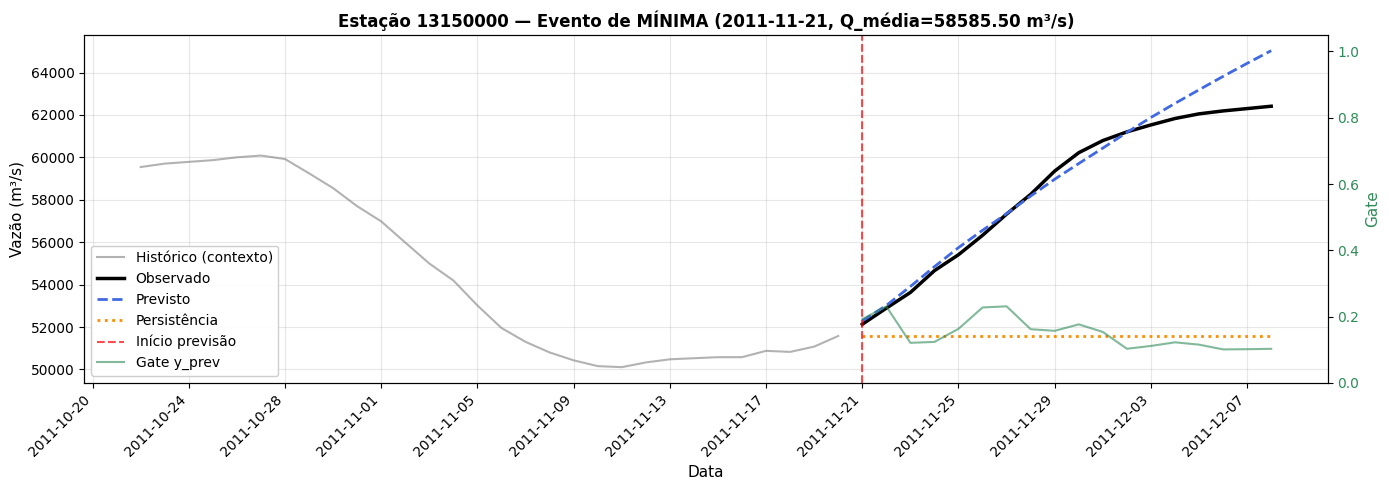

📊 Estação 14100000:
  Selecionados 5 eventos de MÍNIMA vazão
    1º: 2011-11-17 — Vazão média: 57426.85 m³/s
    2º: 2011-11-18 — Vazão média: 57919.36 m³/s
    3º: 2011-11-19 — Vazão média: 58438.67 m³/s
    4º: 2011-11-20 — Vazão média: 58989.36 m³/s
    5º: 2011-11-21 — Vazão média: 59568.05 m³/s



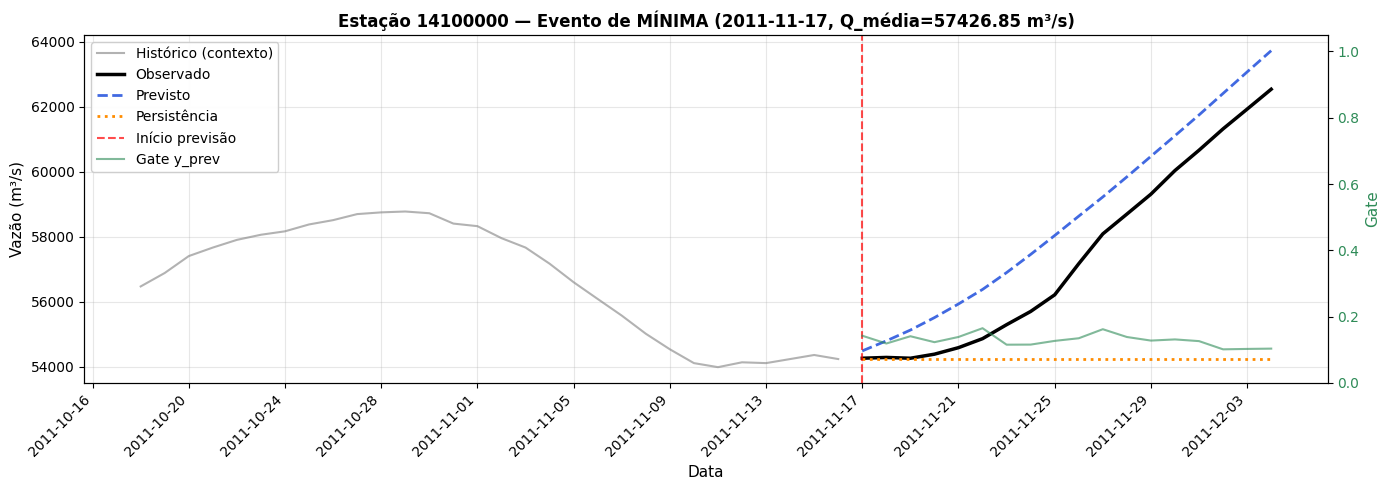

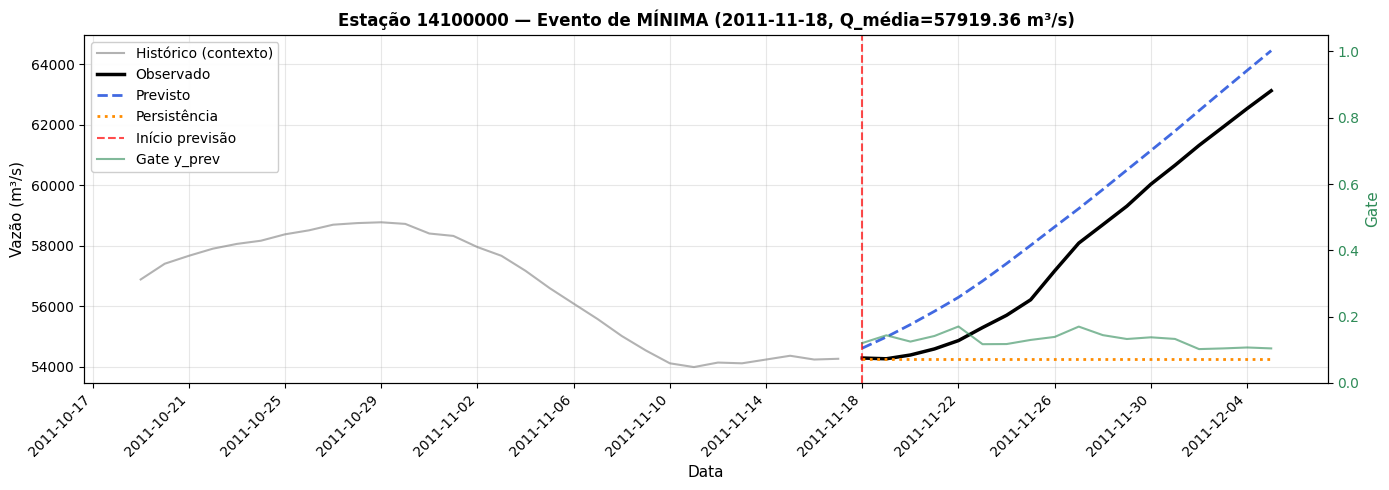

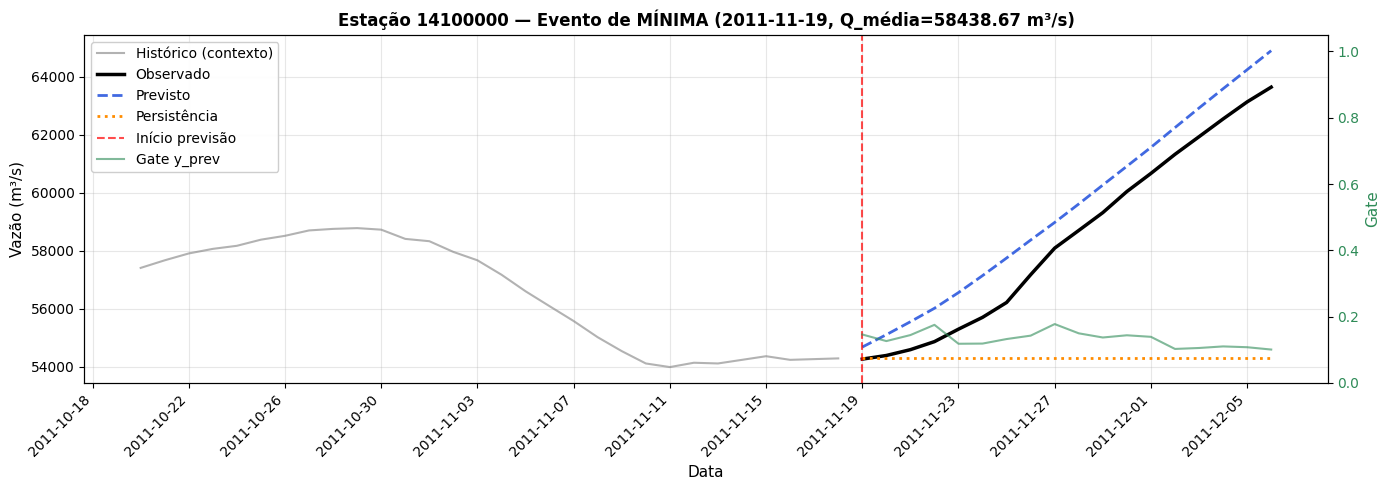

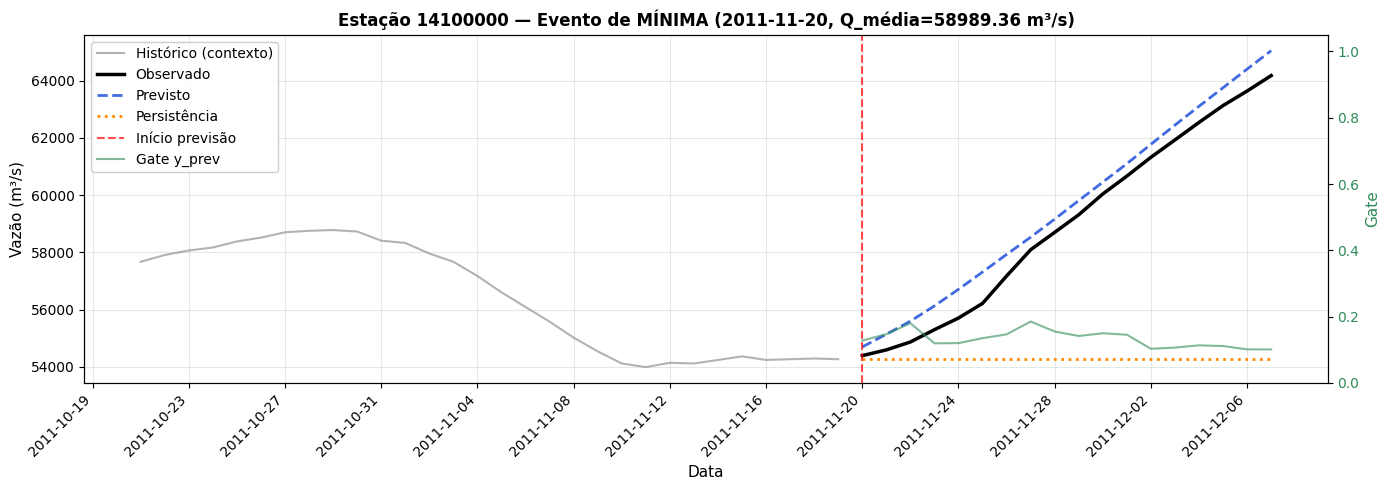

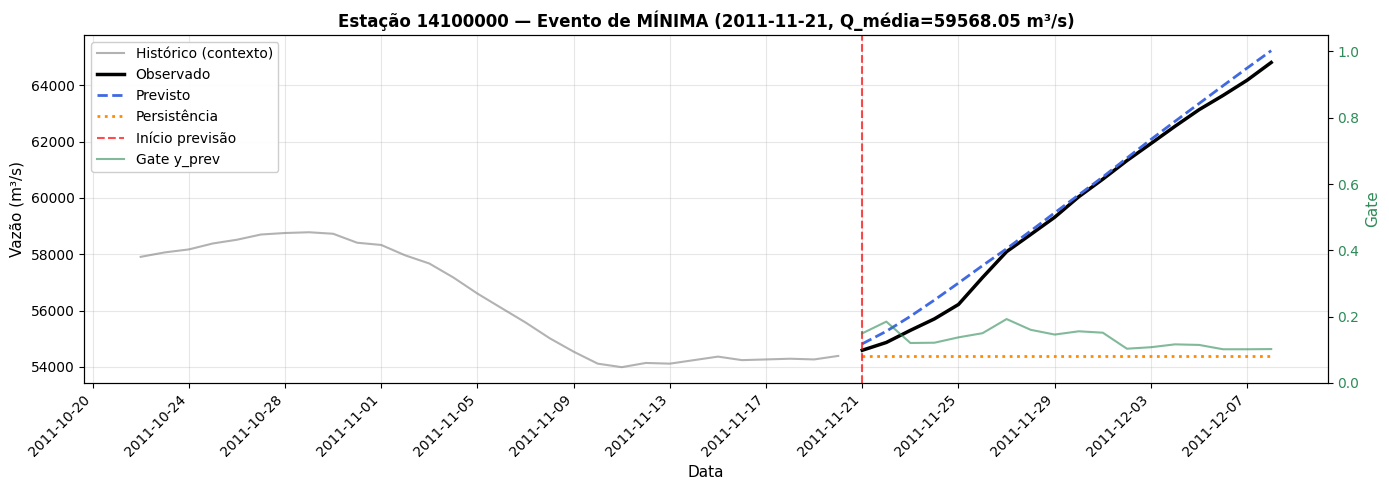

✅ VISUALIZAÇÃO DE EXTREMOS CONCLUÍDA



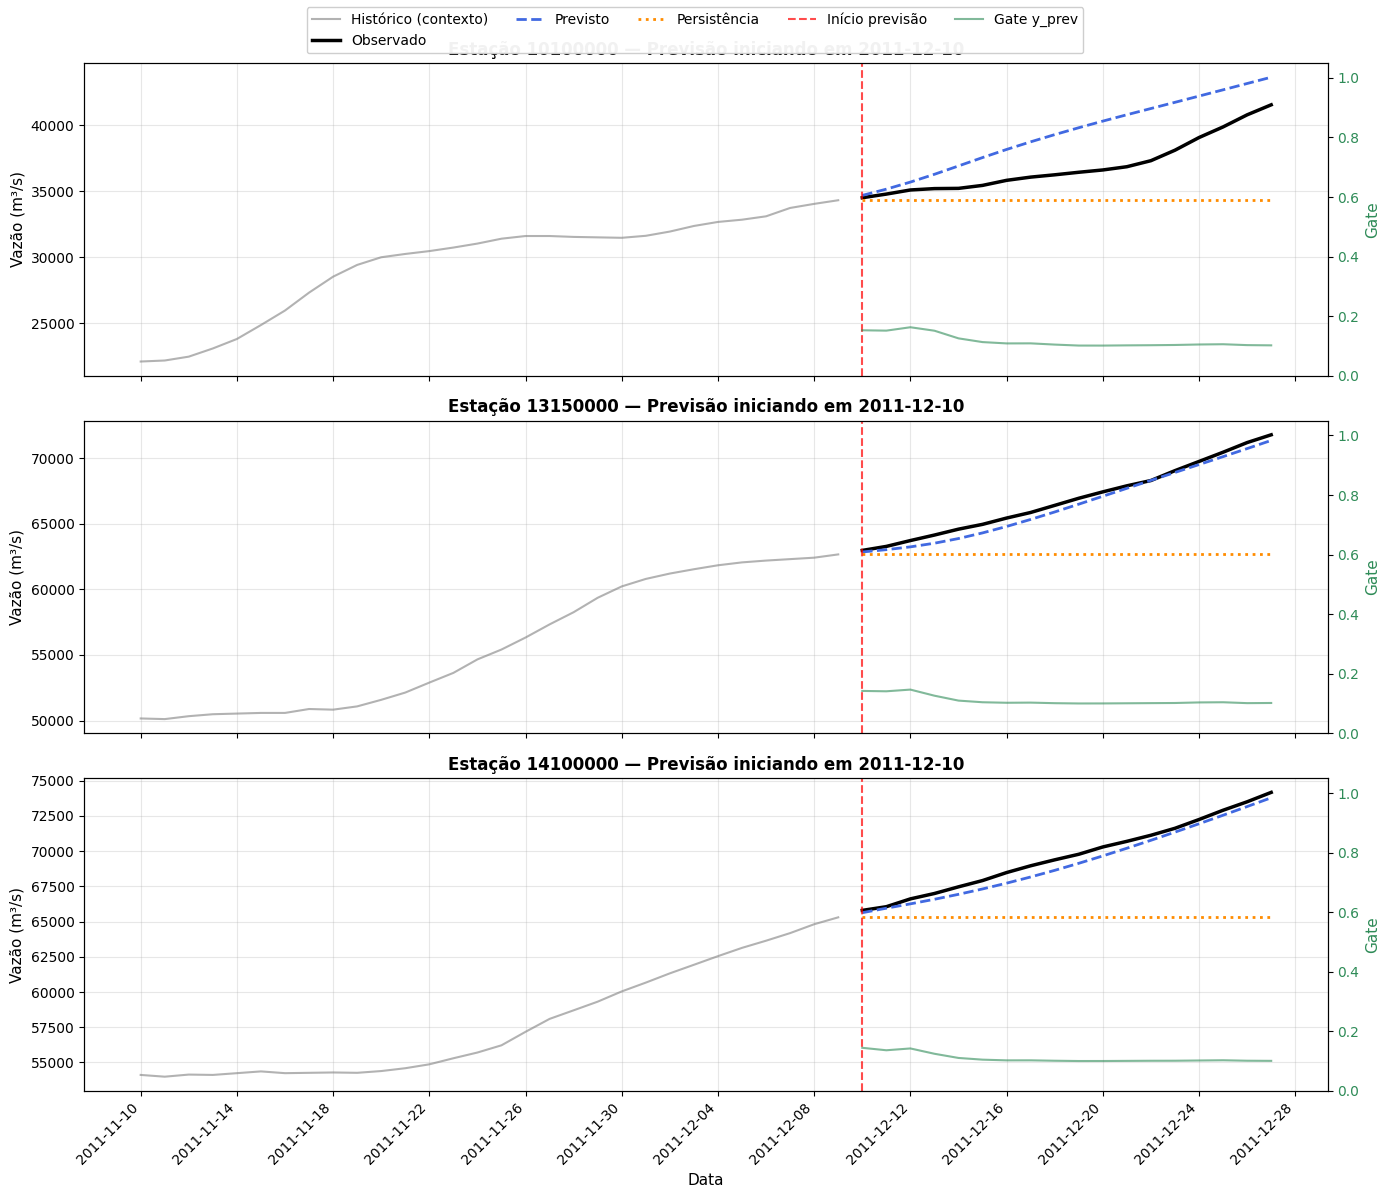

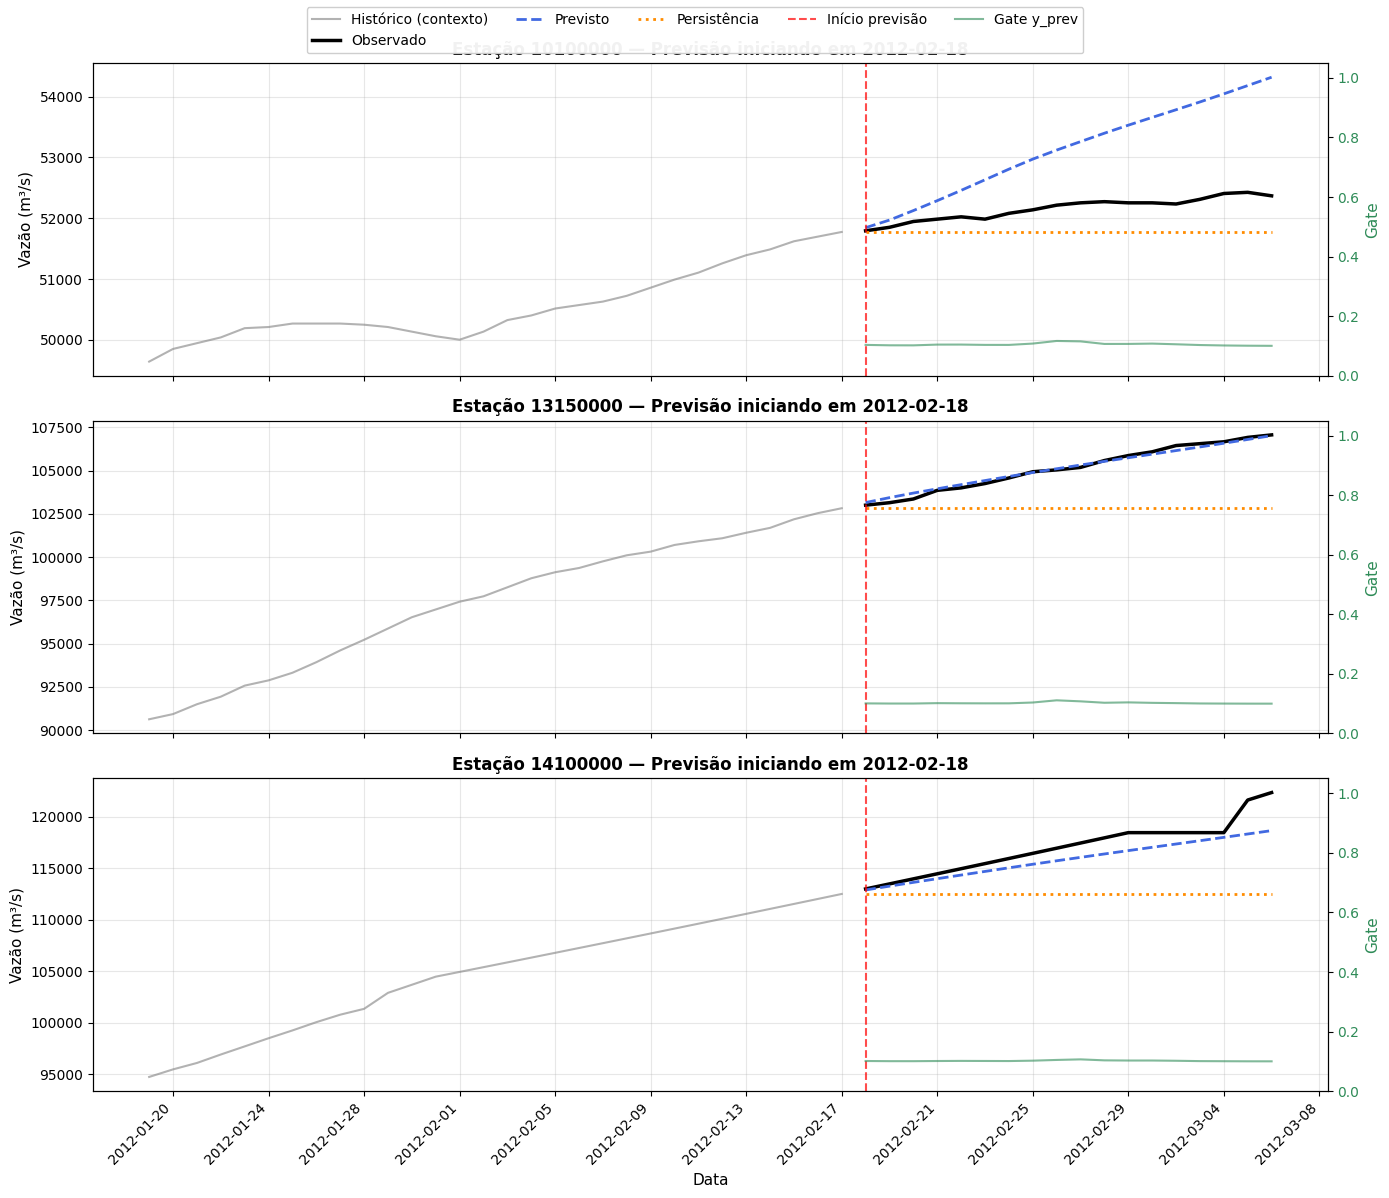

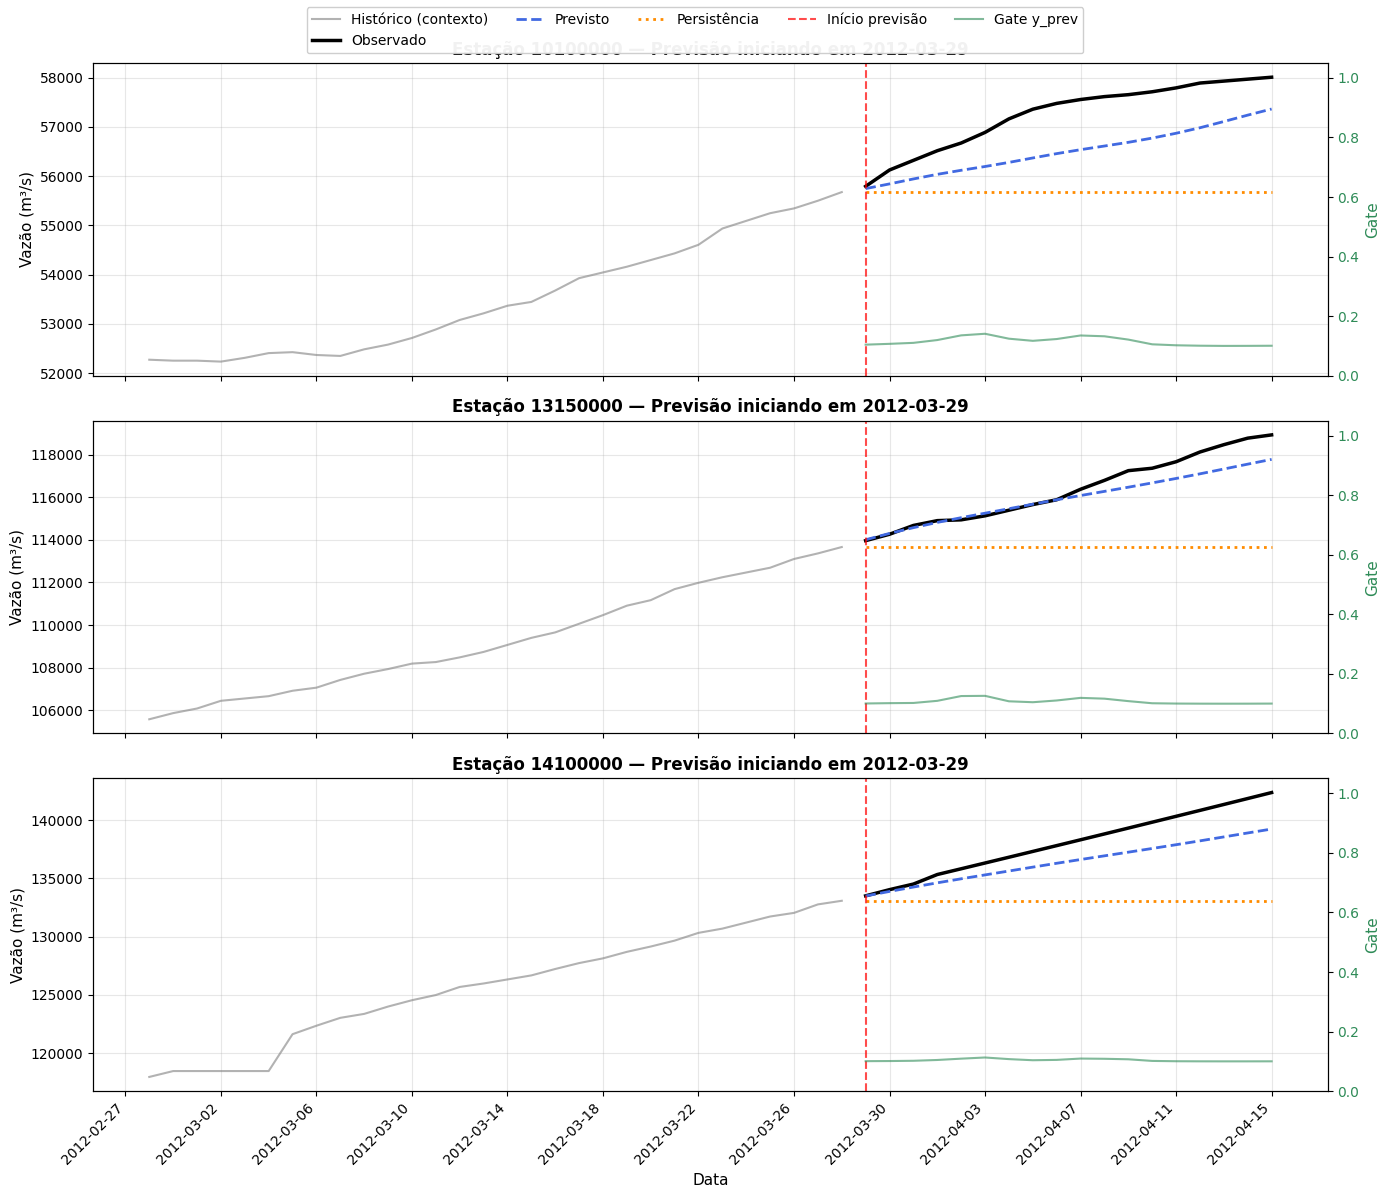

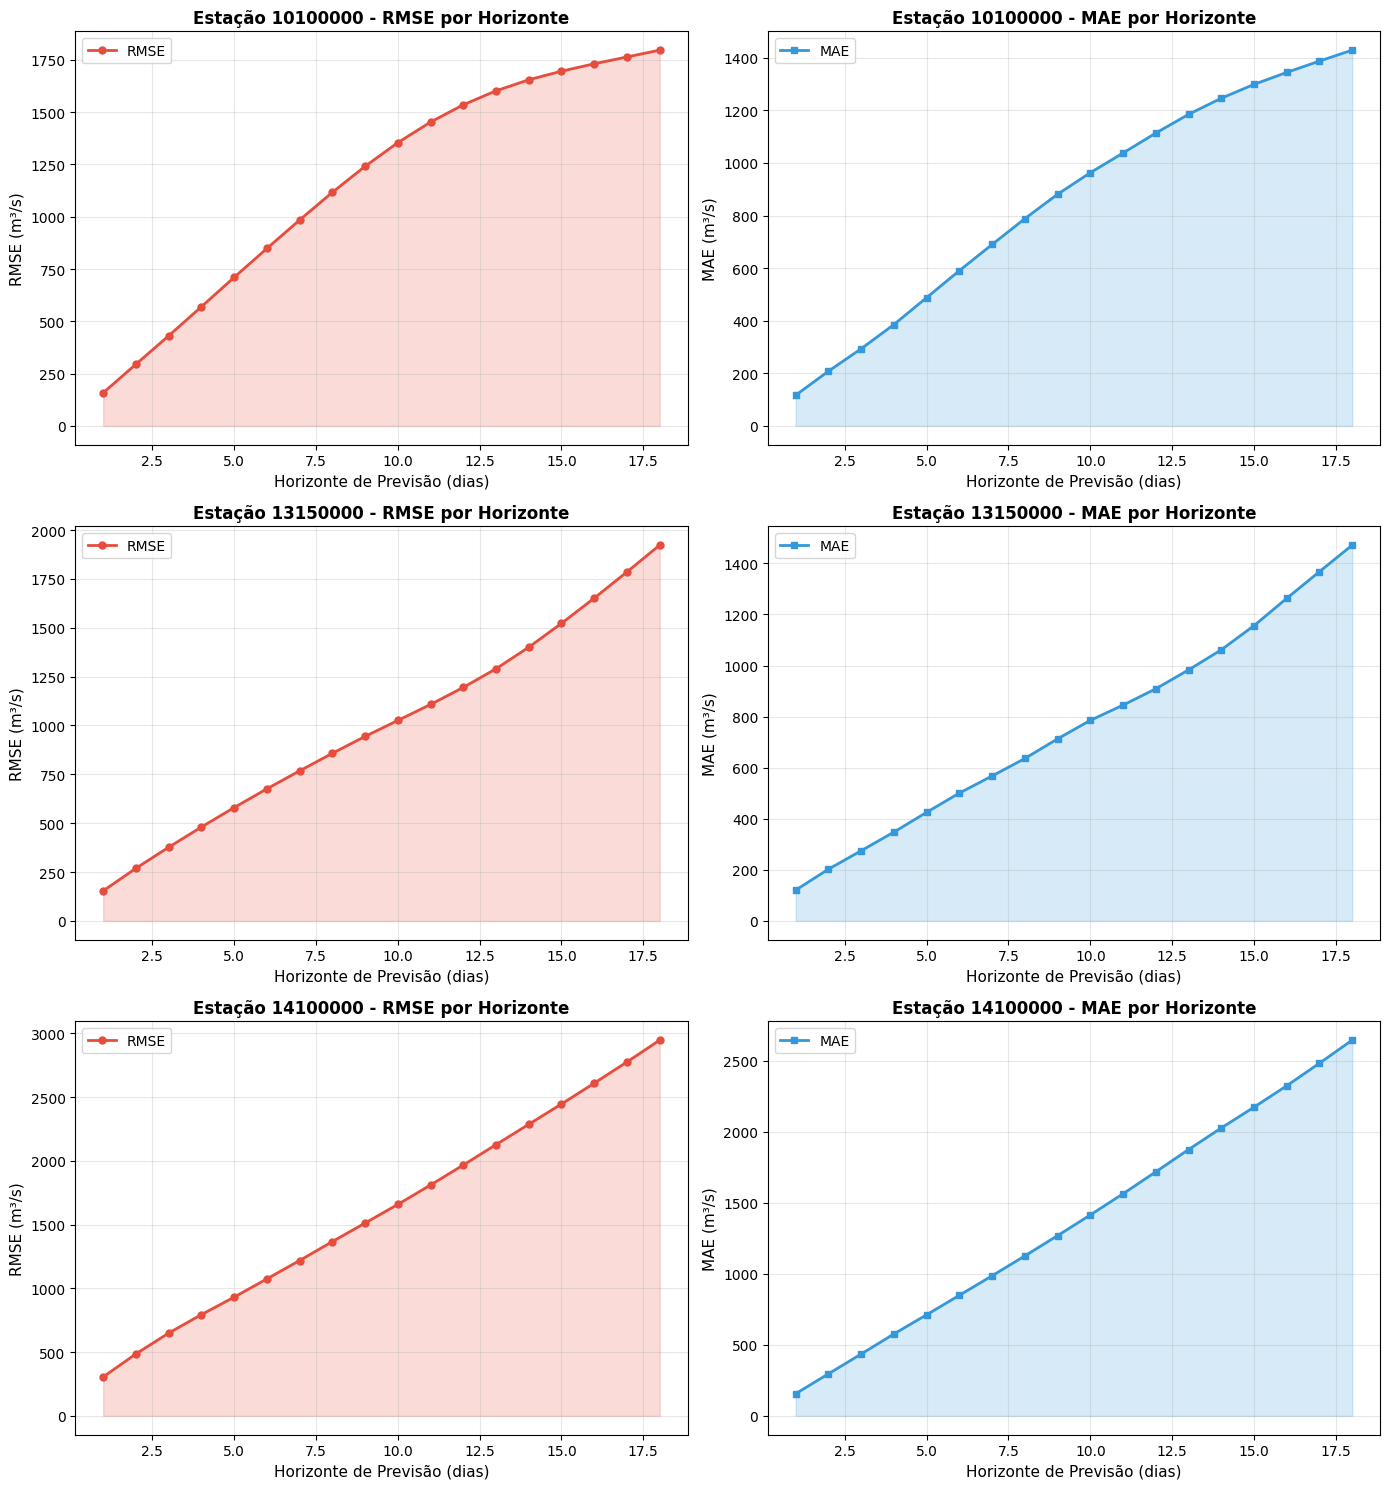

In [6]:
# ==========================================
# IMPORTAÇÕES
# ==========================================
from src import (
    plot_full_series_with_d1_forecast,
    plot_predictions_extremes,
    plot_predictions_with_context,
    plot_metrics_by_horizon
)

# ==========================================
# 1. SÉRIE COMPLETA COM PREVISÕES D+1
# ==========================================
# Visualizar toda a série do período com previsões de 1 dia à frente

plot_full_series_with_d1_forecast(
    preds=preds,              # Previsões: shape (batch, horizon, n_stations)
    obs=obs,                  # Observações: shape (batch, horizon, n_stations)
    stations=stations,            # Lista: [10100000, 13150000, 14100000]
    forecast_dates=dates,     # Datas de início de cada previsão
    df=combined_df,               # DataFrame com índice temporal (features_combined)
    period_name="Validação",      # Nome do período
    baseline_last=baseline,   # Baseline de persistência (opcional)
    figsize=(16, 5)              # Tamanho da figura
)

# Para o período de TESTE:
plot_full_series_with_d1_forecast(
    preds=preds,
    obs=obs,
    stations=stations,
    forecast_dates=dates,
    df=combined_df,
    period_name="Teste",
    baseline_last=baseline,
    figsize=(16, 5)
)

# ==========================================
# 2. EVENTOS EXTREMOS - VAZÕES MÁXIMAS
# ==========================================
# Seleciona e plota os 3 eventos de maior vazão

plot_predictions_extremes(
    preds=preds,             # Previsões
    obs=obs,                 # Observações
    stations=stations,            # Lista de estações
    df=combined_df,               # DataFrame original
    forecast_dates=dates,    # Datas das previsões
    n_samples=3,                  # Número de eventos a mostrar
    extreme_type='max',           # 'max' para máximas
    context_days=30,              # Dias de contexto histórico
    baseline_last=baseline,  # Baseline (opcional)
    g_seq=g_seq              # Gates (opcional)
)

# ==========================================
# 3. EVENTOS EXTREMOS - VAZÕES MÍNIMAS
# ==========================================
# Seleciona e plota os 5 eventos de menor vazão

plot_predictions_extremes(
    preds=preds,
    obs=obs,
    stations=stations,
    df=combined_df,
    forecast_dates=dates,
    n_samples=5,                  # 5 eventos
    extreme_type='min',           # 'min' para mínimas
    context_days=30,
    baseline_last=baseline,
    g_seq=g_seq
)

# ==========================================
# 4. PREVISÕES ALEATÓRIAS COM CONTEXTO
# ==========================================
# Plota algumas previsões aleatórias com contexto histórico

plot_predictions_with_context(
    preds=preds,
    obs=obs,
    stations=stations,
    df=combined_df,
    forecast_dates=dates,
    n_samples=3,                  # 3 amostras aleatórias
    context_days=30,
    baseline_last=baseline,
    g_seq=g_seq
)

# ==========================================
# 5. MÉTRICAS POR HORIZONTE
# ==========================================
# Plota evolução das métricas ao longo do horizonte de previsão

from src import compute_flow_metrics

# Calcular métricas
metrics = compute_flow_metrics(
    preds=preds,
    obs=obs,
    stations=stations,
    baseline_last=baseline,
    horizon_weights=None,  # Pesos iguais para todos os horizontes
    eps=1e-6
)

# Plotar métricas por horizonte
plot_metrics_by_horizon(
    metrics=metrics,
    stations=stations,
    figsize=(14, 5)
)

In [ ]:
# Verificar as datas
print("Primeiras 5 forecast_dates:")
print(pd.to_datetime(dates[:5]))

print("\nPrimeiras 5 datas no combined_df:")
print(combined_df.index[:5])

print("\nÚltimas observações no histórico:")
# Pegar o primeiro batch do DataLoader
for batch in dl_inference:
    print("Shape decoder_history:", batch.decoder_dyn.shape)
    print("Último valor do histórico:", batch.decoder_dyn[0, -1, :])
    print("Target (valores a prever):", batch.target[0, 0, :])
    print("Data do batch:", batch.date[0] if hasattr(batch, 'date') else "Não tem date")
    break

# Comparar persistência com observado
print("\nComparação Persistência vs Observado:")
for i in range(3):
    fc_date = pd.to_datetime(dates[i])
    print(f"\nPrevisão {i}:")
    print(f"  forecast_date: {fc_date}")
    print(f"  baseline_last: {baseline[i, 0]:.2f}")  # Estação 0
    print(f"  obs D+1: {obs[i, 0, 0]:.2f}")  # Estação 0, dia 0
    
    # Ver o que está no combined_df nessa data
    if fc_date in combined_df.index:
        print(f"  combined_df Q em {fc_date}: {combined_df.loc[fc_date, 'Q_10100000']:.2f}")
    
    # Ver o dia anterior
    prev_date = fc_date - timedelta(days=1)
    if prev_date in combined_df.index:
        print(f"  combined_df Q em {prev_date}: {combined_df.loc[prev_date, 'Q_10100000']:.2f}")

Primeiras 5 forecast_dates:
DatetimeIndex(['2011-11-17', '2011-11-18', '2011-11-19', '2011-11-20',
               '2011-11-21'],
              dtype='datetime64[ns]', freq=None)

Primeiras 5 datas no combined_df:
DatetimeIndex(['1995-01-01', '1995-01-02', '1995-01-03', '1995-01-04',
               '1995-01-05'],
              dtype='datetime64[ns]', name='date', freq=None)

Últimas observações no histórico:
Shape decoder_history: torch.Size([1, 153, 48])
Último valor do histórico: tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0479,  0.6300,
         0.8698,  0.9570,  0.5034,  0.8706,  0.7523,  0.9575,  0.6116,  0.7266,
         0.7690,  0.7863,  0.7808,  0.7441, -0.8037,  0.5056,  0.5984,  0.6817,
         0.2161,  0.5989,  0.5777,  0.6819,  0.1752,  0.3852,  0.4853,  0.5758,
         0.5986,  0.5796, -0.8712,  0.3570,  0.5410,  0.5058,  0.1401,  0.5415,
         0.5096,  0.5064,  0.1086,  0.2880,  0.3687,  0.4360,  0.4485,  0.4143])
Target (valores a prever): tensor

: 